### Code Modification Progress

As the competition progressed, the code underwent several critical modifications, each driven by observations from query results, insights from course materials, or a combination of both.

#### Initial Exploration and First Challenges

* **Initial Setup:** Implemented the core BO loop using `sklearn.gaussian_process.GaussianProcessRegressor` and `skopt.dummy_minimize` with `gaussian_ei` for minimization (targeting outputs closest to zero). The simulated objective functions were initially defined with a simple `np.abs(np.sum(...) - ...)` structure, which unfortunately had its minimum at `[0,0,0,0]`.
* **Observation:** The first few suggested queries often converged to `[0,0,0,0]` or other boundary points, yielding outputs that were not significantly better than the initial best, or even worse. This was an early indicator that our simulated function's landscape was simpler than intended or that the optimizer was not exploring effectively.
* **Material Learned/Reasoning:** This highlighted the importance of a well-defined simulated objective function that truly mimics the "many local optima" and non-trivial nature of a real dynamical system. The initial `[0,0,0,0]` optimum was not realistic.

#### Addressing Simulated Function & GP Robustness

* **Change 1: Redefining Simulated Objective Functions:**
    * **Reason:** To create a more challenging and realistic landscape with a non-trivial optimum and multiple local optima, as hinted by the problem. The original `[0,0,0,0]` optimum was too easy for the optimizer.
    * **Modification:** Introduced `opt_point = np.array([0.5, 0.5, 0.5, 0.5])` and used `np.sum((hyperparameters - opt_point)**2)` to create a global minimum at `[0.5, 0.5, 0.5, 0.5]`. Added `np.sin` and `np.cos` terms with multipliers (`*5`, `*2.5`) to create local optima and complexity. Differentiated noise levels between low and high fidelity.
    * **Impact on Score:** This change was crucial for making the problem representative. While it didn't immediately "improve" the score in terms of finding a better global minimum, it set the stage for the BO to actually work on a complex landscape. The previous version would just converge to the trivial `[0,0,0,0]`.

* **Change 2: Robustifying `GaussianProcessRegressor`:**
    * **Reason:** Observed `ConvergenceWarning: lbfgs failed to converge` and kernel parameter hitting bounds (`constant_value` to 1000.0, `length_scale` to 0.01). This meant the GP was struggling to model the function accurately, making its predictions and the acquisition function unreliable.
    * **Modification:**
        * Increased `n_restarts_optimizer` from 9 to 20.
        * Added `alpha=1e-5` to `GaussianProcessRegressor` for numerical stability (a small noise term).
        * Set `normalize_y=True` to help with scaling.
        * Explicitly set `optimizer="fmin_l_bfgs_b"` and used `optimizer_kwargs={"max_iter": 10000}` to give the internal L-BFGS-B optimizer more iterations.
        * Widened kernel bounds for C (1e-4 to 1e4) and RBF `length_scale` (1e-3 to 1e3).
    * **Impact on Score:** These changes significantly improved the reliability of the GP model. While the suggested queries might still have led to non-optimal outputs in some iterations, the GP itself was now better at fitting the observed data and providing more accurate uncertainty estimates. This laid the groundwork for future score improvements.

### Refined Acquisition & Local Search

* **Change 3: Enhancing `dummy_minimize` for Acquisition Function Optimization:**
    * **Reason:** Even with a robust GP, `dummy_minimize` with `n_calls=100` might not effectively find the true peak of the acquisition function. This could lead to suboptimal query suggestions.
    * **Modification:** Increased `n_calls` in `dummy_minimize` from 100 to 500 (and later could be increased to 1000 or more). This provides `dummy_minimize` with more random samples to evaluate the acquisition function, leading to a better next query selection.
    * **Impact on Score:** This was a direct improvement to the acquisition strategy, allowing the Bayesian Optimizer to pick more promising points. It increased the efficiency of finding better points per iteration.

* **Change 4: Explicitly Guiding `dummy_minimize` (`x0` parameter):**
    * **Reason:** To ensure the acquisition function optimizer (`dummy_minimize`) focuses its local search around the best-known regions, especially important given "many local optima."
    * **Modification:** Passed `x0=[current_best_observed_input]` to `dummy_minimize`. Also added `np.clip` with `epsilon` to `x0` values to ensure they are strictly within (0, 1) bounds, preventing `RuntimeError`.
    * **Impact on Score:** This provided a strong bias towards exploitation, helping the BO to refine solutions in known good areas. When combined with increased `n_calls`, it improved the chances of finding local optima more precisely.

* **Change 5: Attempting Inverse Prediction (Predicting inputs for a target output):**
    * **Reason:** To explore if the trained GP could be used to directly predict hyperparameters for a desired outcome (e.g., output = 2.0).
    * **Modification:** Implemented `find_target_output_objective` for `scipy.optimize.minimize` (using `L-BFGS-B`).
    * **Impact on Score:** This was an exploratory step for understanding the GP's capabilities. While it might not have directly impacted the main minimization competition score, it demonstrated advanced usage of the GP. The results (e.g., predicting ~19.93 when aiming for 2.0) highlighted the GP's limitations when data is sparse in the target region or when the function is highly oscillatory. This indicated that for actual score improvement, continuing to focus on Expected Improvement for minimization was the priority.

**Final Result**

Based on the provided snippets, the competition appears to have concluded after 20 iterations of Bayesian Optimization.

* **Final Best Score:** The best overall output (closest to 0) found was `0.07001556866815739` at hyperparameters `[0.86021898 0.61949646 0.6574198 0.20293522]`. This is a significant improvement over your initial best of `-4.025542281908162` and definitely much better than the `~20.0` outputs observed from the earlier runs. The negative outputs seen at the very beginning of the competition have effectively been mitigated.
* **Overall Improvement:** The optimization successfully moved the output from initial values around -20 to -4 down to 0.07. This indicates that the iterative Bayesian Optimization process, with the implemented refinements, was effective in navigating the 4-dimensional hyperparameter space and finding a near-optimal solution (closest to zero difference).

**Actions to Improve Code (If More Weeks Available):**

* **More Iterations (Higher `n_calls`):** The current 100 calls are relatively small for a noisy, multi-modal function. A significantly higher number of calls (e.g., 500-1000) would allow the Bayesian Optimization algorithm more opportunity to explore the landscape and converge to a better global optimum, especially if the surrogate model's uncertainty is guiding it to new, unexplored regions.
* **Adaptive `n_calls` / Optimizer:** Instead of a fixed `n_calls=500` for `dummy_minimize`, one could implement a more sophisticated optimizer for the acquisition function (e.g., using `scipy.optimize.minimize` with multiple restarts and more robust methods) or adapt `n_calls` dynamically.
* **Advanced Kernels:** Explore more complex kernels for `GaussianProcessRegressor` (e.g., Matern kernels with tunable `nu`, RationalQuadratic kernels) if the function's true behavior is very complex or exhibits multi-scale properties. This requires fine-tuning their parameters.
* **Ensemble of GPs:** For highly challenging functions, an ensemble of GP models (each with different kernel parameters or initializations) could be used, and their acquisition functions combined.
* **Multi-Fidelity Acquisition Function (True HK):** If the `GPy` (or `GPflow`) dependency issues were resolved, implementing a true multi-fidelity acquisition function that intelligently decides between low-cost (low-fidelity) and high-cost (high-fidelity) evaluations would be the most impactful improvement. This would significantly reduce the number of expensive `high_fidelity_objective` calls.
* **Constraint Handling:** If any hyperparameters have non-linear constraints, these would need to be incorporated into the optimization.

**What I Would Do Differently if I Started Over Again:**

* **Prioritize a More Robust Surrogate:** Immediately ensure the `objective_function` either calls the actual machine learning model (if available) or uses a more sophisticated surrogate within `skopt`'s `gp_minimize`. Relying on `griddata(method='nearest')` for the core objective function was a simplification for demonstration but could mask the true potential of the optimizer if the "model" was more complex. I would have focused on how to make the `objective_function` a faithful (negative) log-likelihood evaluation of the unknown ML model, rather than relying on a simplistic interpolation.
* **Systematic Hyperparameter Tuning:** From the outset, I would set up a more systematic way to evaluate the impact of `xi` and `n_calls` across multiple runs, perhaps by defining a small grid of these hyperparameters and comparing the best log-likelihood achieved over a fixed budget of evaluations.
* **Early Visualization of Acquisition Function:** While the visualization was introduced, I would integrate plotting the acquisition function much earlier in the process. This visual insight into where the algorithm wants to explore provides immediate feedback on whether it's stuck or genuinely exploring new, promising regions.
* **Consider Hybrid Approaches:** For a problem explicitly stating "many local optima," I might have considered a hybrid approach earlier, perhaps a small number of random searches to get diverse initial points before fully committing to Bayesian Optimization, or even using a genetic algorithm as a strong global explorer before fine-tuning with BO.

In [ ]:
import numpy as np

def objective_function(input):
    # Assume this function represents your machine learning model
    # and returns the difference between the expensive calculation
    # and the model's prediction for the given input (hyperparameters)
    # Replace this with your actual model evaluation logic

    # Placeholder for the output calculation.
    # Replace this comment and the following line with your actual logic.
    output = sum(input)  # Example: Simple sum of input values

    return output

def hill_climbing(initial_input, step_size, max_iterations):
    current_input = initial_input
    current_output = objective_function(current_input)

    for _ in range(max_iterations):
        # Generate neighboring solutions
        neighbor = current_input + np.random.uniform(-step_size, step_size, size=current_input.shape)

        # Evaluate the neighbor
        neighbor_output = objective_function(neighbor)

        # Update if the neighbor is better
        if abs(neighbor_output) < abs(current_output):
            current_input = neighbor
            current_output = neighbor_output

    return current_input, current_output

# Start with the input that resulted in the smallest output (closest to 0)
initial_input = initial_inputs[np.argmin(np.abs(initial_outputs))]

# Set hyperparameters for the hill climbing algorithm
step_size = 0.1
max_iterations = 1000

# Run the optimization
best_input, best_output = hill_climbing(initial_input, step_size, max_iterations)

print("Optimized Input:", best_input)
print("Optimized Output:", best_output)

In [ ]:
import numpy as np

initial_inputs = np.array([
    [0.89698105, 0.72562797, 0.17540431, 0.70169437],
    [0.8893564, 0.49958786, 0.53926886, 0.50878344],
    [0.25094624, 0.03369313, 0.14538002, 0.49493242],
    [0.34696206, 0.0062504, 0.76056361, 0.61302356],
    [0.12487118, 0.12977019, 0.38440048, 0.2870761],
    [0.80130271, 0.50023109, 0.70664456, 0.19510284],
    [0.24770826, 0.06044543, 0.04218635, 0.44132425],
    [0.74670224, 0.7570915, 0.36935306, 0.20656628],
    [0.40066503, 0.07257425, 0.88676825, 0.24384229],
    [0.6260706, 0.58675126, 0.43880578, 0.77885769],
    [0.95713529, 0.59764438, 0.76611385, 0.77620991],
    [0.73281243, 0.14524998, 0.47681272, 0.13336573],
    [0.65511548, 0.07239183, 0.68715175, 0.08151656],
    [0.21973443, 0.83203134, 0.48286416, 0.08256923],
    [0.48859419, 0.2119651, 0.93917791, 0.37619173],
    [0.16713049, 0.87655456, 0.21723954, 0.95980098],
    [0.21691119, 0.16608583, 0.24137226, 0.77006248],
    [0.38748784, 0.80453226, 0.75179548, 0.72382744],
    [0.98562189, 0.66693268, 0.15678328, 0.8565348],
    [0.03782483, 0.66485335, 0.16198218, 0.25392378],
    [0.68348638, 0.9027701, 0.33541983, 0.99948256],
    [0.17034731, 0.75695908, 0.27652049, 0.5312315],
    [0.85965692, 0.91959232, 0.20613873, 0.09779683],
    [0.28213837, 0.50598691, 0.53053084, 0.09630162],
    [0.32607578, 0.4723669, 0.453192, 0.10588734],
    [0.94838936, 0.89451301, 0.85163782, 0.55219629],
    [0.66495539, 0.04656628, 0.11677747, 0.79371778],
    [0.57776561, 0.42877174, 0.42582587, 0.24900741],
    [0.73861301, 0.48210263, 0.70936644, 0.50397001],
    [0.8548108, 0.49396462, 0.73530997, 0.80809201]
])

initial_outputs = np.array([
    -22.10828779, -14.60139663, -11.69993246, -16.05376511, -10.0

In [ ]:
import numpy as np

# Load the initial inputs and outputs from the .npy files
initial_inputs = np.load('/content/initial_inputs.npy')
initial_outputs = np.load('/content/initial_outputs.npy')

print("Initial Inputs Shape:", initial_inputs.shape)
print("Initial Outputs Shape:", initial_outputs.shape)
print("Initial Inputs:\n", initial_inputs)
print("Initial Outputs:\n", initial_outputs)

# Find the input that resulted in the smallest output (closest to 0)
best_index = np.argmin(np.abs(initial_outputs))
best_input = initial_inputs[best_index]

print("\nInput with smallest absolute output:")
print(best_input)
print("Output value:", initial_outputs[best_index])

In [ ]:
import numpy as np

def objective_function(input):
    # Assume this function represents your machine learning model
    # and returns the difference between the expensive calculation
    # and the model's prediction for the given input (hyperparameters)
    # Replace this with your actual model evaluation logic

    # Placeholder for the output calculation.
    # Replace this comment and the following line with your actual logic.
    # Assume the input is a list or array of 4 values
    # This example assumes you want to minimize the sum of the inputs
    output = sum(input)

    return output

def hill_climbing(initial_input, step_size, max_iterations):
    current_input = initial_input
    current_output = objective_function(current_input)

    for _ in range(max_iterations):
        # Generate neighboring solutions
        neighbor = current_input + np.random.uniform(-step_size, step_size, size=current_input.shape)

        # Evaluate the neighbor
        neighbor_output = objective_function(neighbor)

        # Update if the neighbor is better
        if abs(neighbor_output) < abs(current_output):
            current_input = neighbor
            current_output = neighbor_output

    return current_input, current_output

# Your previous query
previous_query = np.array([0.586187, -0.432234, -0.435678, -0.252345])

# Set hyperparameters for the hill climbing algorithm
step_size = 0.1  # You can adjust this
max_iterations = 1000  # You can adjust this

# Run the optimization starting from your previous query
best_input, best_output = hill_climbing(previous_query, step_size, max_iterations)

print("Suggested Next Query:", best_input)
print("Predicted Output:", best_output)

In [ ]:
import numpy as np

initial_inputs = np.load('/content/initial_inputs.npy')
initial_outputs = np.load('/content/initial_outputs.npy')

In [ ]:
new_input = np.array([0.55688, 0.402467, 0.4167, 0.2356])
new_output = np.float64(-4.197386925326807)

updated_inputs = np.vstack([initial_inputs, new_input])
updated_outputs = np.append(initial_outputs, new_output)

In [ ]:
np.save('/content/updated_inputs.npy', updated_inputs)
np.save('/content/updated_outputs.npy', updated_outputs)

In [ ]:
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

print("Updated Inputs Shape:", updated_inputs.shape)
print("Updated Outputs Shape:", updated_outputs.shape)

In [ ]:
print("Updated Inputs Shape:", updated_inputs.shape)
print("Updated Outputs Shape:", updated_outputs.shape)

In [ ]:
import numpy as np

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the updated data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

In [ ]:
import matplotlib.pyplot as plt

# Assuming 'updated_inputs' and 'updated_outputs' are loaded

plt.scatter(updated_inputs[:, 0], updated_inputs[:, 1], c=updated_outputs)
plt.xlabel('Hyperparameter 1')
plt.ylabel('Hyperparameter 2')
plt.colorbar(label='Output')
plt.show()

In [ ]:
import numpy as np

updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

In [ ]:
best_index = np.argmin(np.abs(updated_outputs))
best_input = updated_inputs[best_index]

In [ ]:
step_size = 0.1  # You can adjust this
next_query = best_input + np.random.uniform(-step_size, step_size, size=best_input.shape)

In [ ]:
import numpy as np

updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

best_index = np.argmin(np.abs(updated_outputs))
best_input = updated_inputs[best_index]

step_size = 0.1
next_query = best_input + np.random.uniform(-step_size, step_size, size=best_input.shape)

print("Suggested Next Query:", next_query)

In [ ]:
!pip install scikit-optimize

In [ ]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from skopt.acquisition import gaussian_ei
from skopt import dummy_minimize
from skopt.space import Real  # Import Real

# ... (rest of the code is the same)

# Define the bounds for the hyperparameters using Real objects
bounds = [Real(0, 1), Real(0, 1), Real(0, 1), Real(0, 1)]  # Continuous bounds

# ... (rest of the code is the same)

In [ ]:
!pip install scikit-optimize
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from skopt.acquisition import gaussian_ei
from skopt import dummy_minimize
from skopt.space import Real  # Import Real

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Define the kernel for the Gaussian Process
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))

# Create the Gaussian Process Regressor
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)

# Fit the GPR model to the existing data
gpr.fit(updated_inputs, updated_outputs)

# Define the bounds for the hyperparameters using Real objects
bounds = [Real(0, 1), Real(0, 1), Real(0, 1), Real(0, 1)]  # Continuous bounds

# Function to find the next query using Expected Improvement acquisition function
def next_query(gpr, bounds):
  """
  Finds the next query point using Expected Improvement.

  Args:
    gpr: The fitted Gaussian Process Regressor.
    bounds: The bounds for the hyperparameters.

  Returns:
    The next query point as a numpy array.
  """

  # Use dummy_minimize to find the point that maximizes the acquisition function
  # We use dummy_minimize as a quick way to find the maximum of the acquisition function.
  # More sophisticated optimizers could be used if needed.
  # Reshape x to a 2D array with one row using np.atleast_2d
  # Fix: Access the first element of the gaussian_ei output to get a scalar
  res = dummy_minimize(lambda x: -gaussian_ei(np.atleast_2d(x), gpr, np.min(updated_outputs))[0],  # Maximize Expected Improvement
                      bounds, n_calls=200)
  return res.x

# Get the next query
next_query_point = next_query(gpr, bounds)

# Print the suggested next query
print("Suggested Next Query:", next_query_point)

In [ ]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from skopt.acquisition import gaussian_ei
from skopt import dummy_minimize # Import dummy_minimize

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Define the kernel for the Gaussian Process
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))

# Create the Gaussian Process Regressor
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)

import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from skopt.acquisition import gaussian_ei
from skopt import dummy_minimize # Import dummy_minimize

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Define the kernel for the Gaussian Process
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))

# Create the Gaussian Process Regressor
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)

# Fit the GPR model to the existing data
gpr.fit(updated_inputs, updated_outputs)

# Define the bounds for the hyperparameters
bounds = [(0, 1), (0, 1), (0, 1), (0, 1)]  # Assuming hyperparameters are between 0 and 1

# Function to find the next query using Expected Improvement acquisition function
def next_query(gpr, bounds):
  """
  Finds the next query point using Expected Improvement.

  Args:
    gpr: The fitted Gaussian Process Regressor.
    bounds: The bounds for the hyperparameters.

  Returns:
    The next query point as a numpy array.
  """

  # Use dummy_minimize to find the point that maximizes the acquisition function
  # We use dummy_minimize as a quick way to find the maximum of the acquisition function.
  # More sophisticated optimizers could be used if needed.
  # Reshape x to a 2D array with one row using np.atleast_2d
  # Fix: Access the first element of the gaussian_ei output to get a scalar
  res = dummy_minimize(lambda x: -gaussian_ei(np.atleast_2d(x), gpr, np.min(updated_outputs))[0],  # Maximize Expected Improvement
                      bounds, n_calls=200)
  return res.x

# Get the next query
next_query_point = next_query(gpr, bounds)

# Print the suggested next query
print("Suggested Next Query:", next_query_point)

In [ ]:
import numpy as np

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the updated data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

In [ ]:
import numpy as np

# Load the existing data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Define the new data point
new_input = np.array([0.997573, 0.917024, 0.57929 , 0.598003])
new_output = np.float64(-30.035533906672125)

# Add the new data point to the existing arrays
updated_inputs = np.vstack([updated_inputs, new_input])
updated_outputs = np.append(updated_outputs, new_output)

# Save the updated arrays
np.save('/content/updated_inputs.npy', updated_inputs)
np.save('/content/updated_outputs.npy', updated_outputs)

print("Data appended and saved successfully!")

In [ ]:
import numpy as np

# Load the existing data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Define the new data point
new_input = np.array([0.571673, 0.35481 , 0.35332 , 0.15263 ])
new_output = np.float64(-5.969804799852032)

# Add the new data point to the existing arrays
updated_inputs = np.vstack([updated_inputs, new_input])
updated_outputs = np.append(updated_outputs, new_output)

# Save the updated arrays
np.save('/content/updated_inputs.npy', updated_inputs)
np.save('/content/updated_outputs.npy', updated_outputs)

print("Data appended and saved successfully!")

In [ ]:
import numpy as np

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the updated data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

In [ ]:
!pip install scikit-optimize
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from skopt.acquisition import gaussian_ei
from skopt import dummy_minimize
from skopt.space import Real  # Import Real

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Define the kernel for the Gaussian Process
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))

# Create the Gaussian Process Regressor
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)

# Fit the GPR model to the existing data
gpr.fit(updated_inputs, updated_outputs)

# Define the bounds for the hyperparameters using Real objects
bounds = [Real(0, 1), Real(0, 1), Real(0, 1), Real(0, 1)]  # Continuous bounds

# Function to find the next query using Expected Improvement acquisition function
def next_query(gpr, bounds):
  """
  Finds the next query point using Expected Improvement.

  Args:
    gpr: The fitted Gaussian Process Regressor.
    bounds: The bounds for the hyperparameters.

  Returns:
    The next query point as a numpy array.
  """

  # Use dummy_minimize to find the point that maximizes the acquisition function
  # We use dummy_minimize as a quick way to find the maximum of the acquisition function.
  # More sophisticated optimizers could be used if needed.
  # Reshape x to a 2D array with one row using np.atleast_2d
  # Fix: Access the first element of the gaussian_ei output to get a scalar
  res = dummy_minimize(lambda x: -gaussian_ei(np.atleast_2d(x), gpr, np.min(updated_outputs))[0],  # Maximize Expected Improvement
                      bounds, n_calls=200)
  return res.x

# Get the next query
next_query_point = next_query(gpr, bounds)

# Print the suggested next query
print("Suggested Next Query:", next_query_point)

In [ ]:
!pip install scikit-optimize
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from skopt.acquisition import gaussian_ei
from skopt import dummy_minimize
from skopt.space import Real

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Define the kernel for the Gaussian Process
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))

# Create the Gaussian Process Regressor
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)

# Fit the GPR model to the existing data
gpr.fit(updated_inputs, updated_outputs)

# Define the bounds for the hyperparameters
bounds = [Real(0, 1), Real(0, 1), Real(0, 1), Real(0, 1)]

# Define a starting point for optimization near the best input
starting_point = [0.57776561, 0.42877174, 0.42582587, 0.24900741]

# Function to find the next query, biased towards the starting point
def next_query(gpr, bounds, starting_point):
    """Finds the next query point using Expected Improvement,
       biased towards the starting point."""

    # Use dummy_minimize to find the point that maximizes the acquisition function
    # Starting from the provided starting_point
    res = dummy_minimize(lambda x: -gaussian_ei(np.atleast_2d(x), gpr, np.min(updated_outputs))[0],
                        bounds, n_calls=200, x0=starting_point)  # Start from starting_point
    return res.x

# Get the next query, starting near the best input
next_query_point = next_query(gpr, bounds, starting_point)

# Print the suggested next query
print("Suggested Next Query:", next_query_point)

In [ ]:
!pip install scikit-optimize
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from skopt.acquisition import gaussian_ei
from skopt import dummy_minimize
from skopt.space import Real

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Define the kernel for the Gaussian Process
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))

# Create the Gaussian Process Regressor
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)

# Fit the GPR model to the existing data
gpr.fit(updated_inputs, updated_outputs)

# Define a starting point for optimization near the best input
starting_point = [0.57776561, 0.42877174, 0.42582587, 0.24900741]

# Reduced search space, centered around the starting_point, with a radius of 0.25
bounds = [Real(max(0, starting_point[i] - 0.25), min(1, starting_point[i] + 0.25)) for i in range(4)]

# Function to find the next query, biased towards the starting point
def next_query(gpr, bounds, starting_point):
    """Finds the next query point using Expected Improvement,
       biased towards the starting point."""

    # Use dummy_minimize to find the point that maximizes the acquisition function
    # Starting from the provided starting_point
    res = dummy_minimize(lambda x: -gaussian_ei(np.atleast_2d(x), gpr, np.min(updated_outputs))[0],
                        bounds, n_calls=200, x0=starting_point)  # Start from starting_point
    return res.x

# Get the next query, starting near the best input
next_query_point = next_query(gpr, bounds, starting_point)

# Print the suggested next query
print("Suggested Next Query:", next_query_point)

In [ ]:
import numpy as np

# Load the existing data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Define the new input array
new_input = np.array([0.803482, 0.677055, 0.67563 , 0.090316])

# Add the new input to updated_inputs
updated_inputs = np.vstack([updated_inputs, new_input])

# Save the updated inputs
np.save('/content/updated_inputs.npy', updated_inputs)

print("New input added and saved successfully!")

In [ ]:
import numpy as np

# Load the existing data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Define the new output value
new_output = np.float64(-19.411223333392694)

# Add the new output to updated_outputs
updated_outputs = np.append(updated_outputs, new_output)

# Save the updated outputs
np.save('/content/updated_outputs.npy', updated_outputs)

print("New output added and saved successfully!")

In [ ]:
import numpy as np

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the updated data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

In [ ]:
!pip install scikit-optimize


In [ ]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from skopt.acquisition import gaussian_ei
from skopt import dummy_minimize
from skopt.space import Real

In [ ]:
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

In [ ]:
def objective_function(hyperparameters):
    """
    This function represents your machine learning model and returns the
    difference between the expensive calculation and the model's prediction.

    Args:
        hyperparameters: A list or array of 4 hyperparameter values.

    Returns:
        The difference between the expensive calculation and the model's prediction.
    """
    # ... (Your existing code to evaluate the model and calculate the difference) ...
    # Replace this with your actual model evaluation logic
    output = sum(hyperparameters) # Example: Simple sum of input values

    return output

In [ ]:
# Define the kernel for the Gaussian Process
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))

# Create the Gaussian Process Regressor
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)

# Define the bounds for the hyperparameters using Real objects
bounds = [Real(0, 1), Real(0, 1), Real(0, 1), Real(0, 1)]  # Continuous bounds

# Function to find the next query using Expected Improvement acquisition function
def next_query(gpr, bounds):
  """
  Finds the next query point using Expected Improvement.

  Args:
    gpr: The fitted Gaussian Process Regressor.
    bounds: The bounds for the hyperparameters.

  Returns:
    The next query point as a numpy array.
  """

  # Use dummy_minimize to find the point that maximizes the acquisition function
  # We use dummy_minimize as a quick way to find the maximum of the acquisition function.
  # More sophisticated optimizers could be used if needed.
  # Reshape x to a 2D array with one row using np.atleast_2d
  # Fix: Access the first element of the gaussian_ei output to get a scalar
  res = dummy_minimize(lambda x: -gaussian_ei(np.atleast_2d(x), gpr, np.min(updated_outputs))[0],  # Maximize Expected Improvement
                      bounds, n_calls=200)
  return res.x

# Define the number of iterations for the Bayesian Optimization loop
num_iterations = 10  # You can change this to your desired number of iterations

# Bayesian Optimization Loop
for i in range(num_iterations):
    # Fit the GPR model to the existing data
    gpr.fit(updated_inputs, updated_outputs)

    # Get the next query point
    next_query_point = next_query(gpr, bounds)

    # Evaluate the objective function at the next query point
    new_output = objective_function(next_query_point)

    # Add the new data point to the existing data
    updated_inputs = np.vstack([updated_inputs, next_query_point])
    updated_outputs = np.append(updated_outputs, new_output)

    # ... (Optional: Save the updated data to files) ...

# Print the best hyperparameters and corresponding output
best_index = np.argmin(updated_outputs)
best_hyperparameters = updated_inputs[best_index]
best_output = updated_outputs[best_index]
print("Best Hyperparameters:", best_hyperparameters)
print("Best Output:", best_output)

ValueError: Found input variables with inconsistent numbers of samples: [38, 39]

In [ ]:
import numpy as np

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Find the indices of the smallest absolute outputs (closest to zero)
# argsort returns the indices that would sort the array
sorted_indices = np.argsort(np.abs(updated_outputs))

# Get the indices of the top 3 smallest outputs
top_3_indices = sorted_indices[:3]

# Get the input combinations corresponding to the top 3 smallest outputs
best_inputs = updated_inputs[top_3_indices]

# Print the best input combinations and their corresponding outputs
for i, input_combination in enumerate(best_inputs):
    output_value = updated_outputs[top_3_indices[i]]
    print(f"Input Combination {i+1}: {input_combination}, Output: {output_value}")

In [ ]:
!pip install scikit-learn
import numpy as np
from sklearn.neighbors import NearestNeighbors

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Best input combinations (from previous output)
best_inputs = np.array([
    [0.57776561, 0.42877174, 0.42582587, 0.24900741],
    [0.55688, 0.402467, 0.4167, 0.2356],
    [0.571673, 0.35481, 0.35332, 0.15263]
])

# Number of neighbors to consider
k = 5  # You can adjust this

# Create NearestNeighbors object
knn = NearestNeighbors(n_neighbors=k)
knn.fit(updated_inputs)

# Find neighbors of the best inputs
distances, indices = knn.kneighbors(best_inputs)

# Generate new queries by perturbing the neighbors
num_queries_per_neighbor = 3  # You can adjust this
step_size = 0.1  # You can adjust this

new_queries = []
for neighbor_indices in indices:
    for i in range(num_queries_per_neighbor):
        # Select a random neighbor
        neighbor_index = np.random.choice(neighbor_indices)
        neighbor = updated_inputs[neighbor_index]

        # Generate a new query by perturbing the neighbor
        new_query = neighbor + np.random.uniform(-step_size, step_size, size=neighbor.shape)

        # Clip the new query to the bounds [0, 1]
        new_query = np.clip(new_query, 0, 1)

        new_queries.append(new_query)

# Convert new queries to a numpy array
new_queries = np.array(new_queries)

# Print the new queries
print("New Queries:")
print(new_queries)

In [ ]:
!pip install scikit-optimize
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from skopt.acquisition import gaussian_ei
from skopt import dummy_minimize
from skopt.space import Real
from sklearn.neighbors import NearestNeighbors

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Best input combinations (from previous output)
best_inputs = np.array([
    [0.57776561, 0.42877174, 0.42582587, 0.24900741],
    [0.55688, 0.402467, 0.4167, 0.2356],
    [0.571673, 0.35481, 0.35332, 0.15263]
])

# Define the kernel for the Gaussian Process
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))

# Create the Gaussian Process Regressor
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)

# Fit the GPR model to the existing data
gpr.fit(updated_inputs, updated_outputs)

# Define the bounds for the hyperparameters
bounds = [(0, 1), (0, 1), (0, 1), (0, 1)]

# Number of neighbors to consider
k = 5

# Create NearestNeighbors object
knn = NearestNeighbors(n_neighbors=k)
knn.fit(updated_inputs)

# Function to find the next query using Expected Improvement and k-NN
def next_query(gpr, bounds, best_inputs, knn):
    """Finds the next query point using Expected Improvement and k-NN."""

    # Find neighbors of the best inputs
    distances, indices = knn.kneighbors(best_inputs)

    # Generate candidate queries by perturbing the neighbors
    num_candidates = 10  # You can adjust this
    step_size = 0.1       # You can adjust this

    candidate_queries = []
    for neighbor_indices in indices:
        for _ in range(num_candidates):
            neighbor_index = np.random.choice(neighbor_indices)
            neighbor = updated_inputs[neighbor_index]

            # Generate a new query by perturbing the neighbor
            new_query = neighbor + np.random.uniform(-step_size, step_size, size=neighbor.shape)

            # Clip the new query to the bounds [0, 1]
            new_query = np.clip(new_query, 0, 1)

            candidate_queries.append(new_query)

    # Select the best candidate based on Expected Improvement
    # Instead of n_initial_points, evaluate EI for each candidate and select the best
    best_ei = -np.inf
    best_candidate = None
    for candidate in candidate_queries:
        ei = gaussian_ei(np.atleast_2d(candidate), gpr, np.min(updated_outputs))[0]
        if ei > best_ei:
            best_ei = ei
            best_candidate = candidate

    return best_candidate


# Get the next query
next_query_point = next_query(gpr, bounds, best_inputs, knn)

# Print the suggested next query
print("Suggested Next Query:", next_query_point)

In [ ]:
import numpy as np

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the updated data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

In [ ]:
import numpy as np

# Load existing data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# New data point
new_input = np.array([0.819339, 0.061384, 0.411419, 0.146965])
new_output = np.float64(-16.590585651720698)

# Add new data to existing arrays
updated_inputs = np.vstack([updated_inputs, new_input])
updated_outputs = np.append(updated_outputs, new_output)

# Save the updated arrays
np.save('/content/updated_inputs.npy', updated_inputs)
np.save('/content/updated_outputs.npy', updated_outputs)

print("Data appended and saved successfully!")

In [ ]:
import numpy as np

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the updated data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

In [ ]:
import numpy as np

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Find the index of the minimum output value
best_index = np.argmin(np.abs(updated_outputs))  # Use np.argmin(np.abs()) to find the closest to 0

# Get the best output and corresponding input
best_output = updated_outputs[best_index]
best_input = updated_inputs[best_index]

print("Best Output:", best_output)
print("Corresponding Input:", best_input)

In [ ]:
import numpy as np

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Find the indices of the smallest absolute outputs (closest to zero)
# argsort returns the indices that would sort the array
sorted_indices = np.argsort(np.abs(updated_outputs))

# Get the indices of the top 4 smallest outputs
top_4_indices = sorted_indices[:4]

# Get the input combinations corresponding to the top 4 smallest outputs
best_inputs = updated_inputs[top_4_indices]

# Print the best input combinations and their corresponding outputs
for i, input_combination in enumerate(best_inputs):
    output_value = updated_outputs[top_4_indices[i]]
    print(f"Input Combination {i+1}: {input_combination}, Output: {output_value}")

In [ ]:
!pip install scikit-learn
import numpy as np
from sklearn.neighbors import NearestNeighbors

# Best input combinations (from previous output)
best_inputs = np.array([
    [0.57776561, 0.42877174, 0.42582587, 0.24900741],
    [0.55688, 0.402467, 0.4167, 0.2356],
    [0.571673, 0.35481, 0.35332, 0.15263],
    [0.32607578, 0.4723669, 0.453192, 0.10588734]
])

# Number of neighbors to consider
k = 5  # You can adjust this

# Create NearestNeighbors object
knn = NearestNeighbors(n_neighbors=k)
knn.fit(updated_inputs) # Assuming updated_inputs is loaded

# Find neighbors of the best inputs
distances, indices = knn.kneighbors(best_inputs)

# Generate new queries by perturbing the neighbors
num_queries_per_neighbor = 3  # You can adjust this
step_size = 0.1  # You can adjust this

new_queries = []
for neighbor_indices in indices:
    for i in range(num_queries_per_neighbor):
        # Select a random neighbor
        neighbor_index = np.random.choice(neighbor_indices)
        neighbor = updated_inputs[neighbor_index]

        # Generate a new query by perturbing the neighbor
        new_query = neighbor + np.random.uniform(-step_size, step_size, size=neighbor.shape)

        # Clip the new query to the bounds [0, 1]
        new_query = np.clip(new_query, 0, 1)

        new_queries.append(new_query)

# Convert new queries to a numpy array
new_queries = np.array(new_queries)

# Print the new queries
print("New Queries:")
print(new_queries)

In [ ]:
!pip install scikit-optimize
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from skopt.acquisition import gaussian_ei
from skopt import dummy_minimize
from skopt.space import Real
from sklearn.neighbors import NearestNeighbors

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Best input combinations (from previous output)
best_inputs = np.array([
    [0.57776561, 0.42877174, 0.42582587, 0.24900741],
    [0.55688, 0.402467, 0.4167, 0.2356],
    [0.571673, 0.35481, 0.35332, 0.15263]
])

# Define the kernel for the Gaussian Process
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))

# Create the Gaussian Process Regressor
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)

# Fit the GPR model to the existing data
gpr.fit(updated_inputs, updated_outputs)

# Define the bounds for the hyperparameters
bounds = [(0, 1), (0, 1), (0, 1), (0, 1)]

# Number of neighbors to consider
k = 5

# Create NearestNeighbors object
knn = NearestNeighbors(n_neighbors=k)
knn.fit(updated_inputs)

# Function to find the next query using Expected Improvement and k-NN
def next_query(gpr, bounds, best_inputs, knn):
    """Finds the next query point using Expected Improvement and k-NN."""

    # Find neighbors of the best inputs
    distances, indices = knn.kneighbors(best_inputs)

    # Generate candidate queries by perturbing the neighbors
    num_candidates = 10  # You can adjust this
    step_size = 0.1       # You can adjust this

    candidate_queries = []
    for neighbor_indices in indices:
        for _ in range(num_candidates):
            neighbor_index = np.random.choice(neighbor_indices)
            neighbor = updated_inputs[neighbor_index]

            # Generate a new query by perturbing the neighbor
            new_query = neighbor + np.random.uniform(-step_size, step_size, size=neighbor.shape)

            # Clip the new query to the bounds [0, 1]
            new_query = np.clip(new_query, 0, 1)

            candidate_queries.append(new_query)

    # Select the best candidate based on Expected Improvement
    # Instead of n_initial_points, evaluate EI for each candidate and select the best
    best_ei = -np.inf
    best_candidate = None
    for candidate in candidate_queries:
        ei = gaussian_ei(np.atleast_2d(candidate), gpr, np.min(updated_outputs))[0]
        if ei > best_ei:
            best_ei = ei
            best_candidate = candidate

    return best_candidate


# Get the next query
next_query_point = next_query(gpr, bounds, best_inputs, knn)

# Print the suggested next query
print("Suggested Next Query:", next_query_point)

In [ ]:
import numpy as np

# Load existing data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# New data point
new_input = np.array([0.798244, 0.199837, 0.532883, 0.037106])
new_output = np.float64(-16.654901808312072)

# Add new data to existing arrays
updated_inputs = np.vstack([updated_inputs, new_input])
updated_outputs = np.append(updated_outputs, new_output)

# Save the updated arrays
np.save('/content/updated_inputs.npy', updated_inputs)
np.save('/content/updated_outputs.npy', updated_outputs)

print("Data appended and saved successfully!")

In [ ]:
import numpy as np

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the updated data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

In [ ]:
!pip install scikit-optimize

import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from skopt.acquisition import gaussian_ei
from skopt import dummy_minimize
from skopt.space import Real

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Define the kernel for the Gaussian Process
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))

# Create the Gaussian Process Regressor
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)

# Fit the GPR model to the existing data
gpr.fit(updated_inputs, updated_outputs)

# Define the bounds for the hyperparameters using Real objects
# Assuming your hyperparameters are between 0 and 1
bounds = [Real(0, 1), Real(0, 1), Real(0, 1), Real(0, 1)]

# Function to find the next query using Expected Improvement acquisition function
def next_query(gpr, bounds, current_best_output):
  """
  Finds the next query point using Expected Improvement.

  Args:
    gpr: The fitted Gaussian Process Regressor.
    bounds: The bounds for the hyperparameters.
    current_best_output: The current minimum observed output value.

  Returns:
    The next query point as a numpy array.
  """

  # Use dummy_minimize to find the point that maximizes the acquisition function
  # We use dummy_minimize as a quick way to find the maximum of the acquisition function.
  # More sophisticated optimizers could be used if needed.
  # Reshape x to a 2D array with one row using np.atleast_2d
  # Access the first element of the gaussian_ei output to get a scalar
  res = dummy_minimize(lambda x: -gaussian_ei(np.atleast_2d(x), gpr, current_best_output)[0],  # Maximize Expected Improvement
                      bounds, n_calls=200) # You can adjust n_calls
  return res.x

# Get the current best output
current_best_output = np.min(updated_outputs)

# Get the next query
next_query_point = next_query(gpr, bounds, current_best_output)

# Print the suggested next query
print("Suggested Next Query:", next_query_point)

In [ ]:
import numpy as np

# Load existing data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# New data point
new_input = np.array([0.969160,0.985958, 0.661042, 0.343027])
new_output = np.float64(-30.77977620268435)

# Add new data to existing arrays
updated_inputs = np.vstack([updated_inputs, new_input])
updated_outputs = np.append(updated_outputs, new_output)

# Save the updated arrays
np.save('/content/updated_inputs.npy', updated_inputs)
np.save('/content/updated_outputs.npy', updated_outputs)

print("Data appended and saved successfully!")

In [ ]:
import numpy as np

# Load existing data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Define the new data point
new_input = np.array([0.565116, 0.422936, 0.338553, 0.205396])
new_output = np.float64(-5.065082308923291)

# Add new data to existing arrays
updated_inputs = np.vstack([updated_inputs, new_input])
updated_outputs = np.append(updated_outputs, new_output)

# Save the updated arrays
np.save('/content/updated_inputs.npy', updated_inputs)
np.save('/content/updated_outputs.npy', updated_outputs)

print("Data appended and saved successfully!")

In [ ]:
import numpy as np

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the updated data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

In [ ]:
import numpy as np

# Load existing data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Define the new data point (input and its corresponding output)
# Make sure to replace these with your actual new data
new_input = np.array([0.969160, 0.985958, 0.661042, 0.343027])  # Example new input
new_output = np.float64(-30.77977620268435) # Example new output

# Add new data to existing arrays simultaneously
updated_inputs = np.vstack([updated_inputs, new_input])
updated_outputs = np.append(updated_outputs, new_output)

# Save the updated arrays
np.save('/content/updated_inputs.npy', updated_inputs)
np.save('/content/updated_outputs.npy', updated_outputs)

print("Data appended and saved successfully!")

# After ensuring the arrays are synchronized, the subsequent cells should work.
# For example, the cell that caused the error:

# Load the updated data (this will now have consistent sizes)
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Find the indices of the smallest absolute outputs (closest to zero)
sorted_indices = np.argsort(np.abs(updated_outputs))

# Get the indices of the top 4 smallest outputs
top_4_indices = sorted_indices[:4]

# Get the input combinations corresponding to the top 4 smallest outputs
# This line will now work as updated_inputs and updated_outputs have the same size
best_inputs = updated_inputs[top_4_indices]

# Print the best input combinations and their corresponding outputs
for i, input_combination in enumerate(best_inputs):
    output_value = updated_outputs[top_4_indices[i]]
    print(f"Input Combination {i+1}: {input_combination}, Output: {output_value}")

In [ ]:
!pip install scikit-optimize

import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from skopt.acquisition import gaussian_ei
from skopt import dummy_minimize
from skopt.space import Real

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# --- FIX: Ensure updated_inputs and updated_outputs have the same length ---
# If the lengths are different, truncate the longer array
if updated_inputs.shape[0] != updated_outputs.shape[0]:
    min_length = min(updated_inputs.shape[0], updated_outputs.shape[0])
    updated_inputs = updated_inputs[:min_length]
    updated_outputs = updated_outputs[:min_length]
    print(f"Warning: Mismatched input/output lengths found. Truncated to {min_length}.")
# --------------------------------------------------------------------------


# Define the kernel for the Gaussian Process
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))

# Create the Gaussian Process Regressor
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)

# Fit the GPR model to the existing data
gpr.fit(updated_inputs, updated_outputs)

# Define the bounds for the hyperparameters using Real objects
# Assuming your hyperparameters are between 0 and 1
bounds = [Real(0, 1), Real(0, 1), Real(0, 1), Real(0, 1)]

# Function to find the next query using Expected Improvement acquisition function
def next_query(gpr, bounds, current_best_output):
  """
  Finds the next query point using Expected Improvement.

  Args:
    gpr: The fitted Gaussian Process Regressor.
    bounds: The bounds for the hyperparameters.
    current_best_output: The current minimum observed output value.

  Returns:
    The next query point as a numpy array.
  """

  # Use dummy_minimize to find the point that maximizes the acquisition function
  # We use dummy_minimize as a quick way to find the maximum of the acquisition function.
  # More sophisticated optimizers could be used if needed.
  # Reshape x to a 2D array with one row using np.atleast_2d
  # Access the first element of the gaussian_ei output to get a scalar
  res = dummy_minimize(lambda x: -gaussian_ei(np.atleast_2d(x), gpr, current_best_output)[0],  # Maximize Expected Improvement
                      bounds, n_calls=200) # You can adjust n_calls
  return res.x

# Get the current best output (the minimum value observed so far)
# Use the potentially truncated updated_outputs to get the minimum
current_best_output = np.min(updated_outputs) # For minimizing, we use the actual minimum value

# Get the next query suggested by optimizing the acquisition function
next_query_point = next_query(gpr, bounds, current_best_output)

# Print the suggested next query
print("Suggested Next Query:", next_query_point)

In [ ]:
import numpy as np

# Load existing data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Define the new data point
new_input = np.array([0.503636, 0.597875, 0.258821, 0.220868])
new_output = np.float64(-6.568059362465117)

# Add new data to existing arrays
updated_inputs = np.vstack([updated_inputs, new_input])
updated_outputs = np.append(updated_outputs, new_output)

# Save the updated arrays
np.save('/content/updated_inputs.npy', updated_inputs)
np.save('/content/updated_outputs.npy', updated_outputs)

print("Data appended and saved successfully!")

In [ ]:
import numpy as np

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the updated data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

In [ ]:
# Assuming all_inputs and all_outputs are already prepared as in your code.
# all_inputs: [spatial_dims | fidelity_index]
# all_outputs: [output_values]

# --- Corrected Multi-Fidelity Gaussian Process Model (using GPy) ---

# Define the kernel for the spatial dimensions (excluding the fidelity index)
# input_dim should be 4 (for x0, x1, x2, x3)
kernel_spatial = GPy.kern.RBF(input_dim=4, active_dims=list(range(4))) # active_dims are 0,1,2,3 for the 4 spatial dims

# Define the coregionalization kernel for multi-fidelity
# input_dim for Coregionalize is 0 because the fidelity index is directly handled by the Y structure in GPCoregionalizedRegression
# output_dim is 2 for two fidelities (low=0 and high=1)
coregionalization_kernel = GPy.kern.Coregionalize(input_dim=0, output_dim=2) # input_dim=0 is key here

# Combine the spatial kernel and coregionalization kernel
# The GPy.prod operation needs compatible kernels.
# For GPCoregionalizedRegression, the coregionalization is handled by the Y input structure.
# So, the main kernel is just the spatial one.

# Filter inputs and outputs by fidelity for GPCoregionalizedRegression
initial_low_inputs_spatial = all_inputs[all_inputs[:, -1] == 0][:, :-1]
initial_high_inputs_spatial = all_inputs[all_inputs[:, -1] == 1][:, :-1]

initial_low_outputs_values = all_outputs[all_inputs[:, -1] == 0]
initial_high_outputs_values = all_outputs[all_inputs[:, -1] == 1]

# Create the lists for X and Y inputs to GPCoregionalizedRegression
# X_list should contain spatial inputs for each fidelity
X_list = [initial_low_inputs_spatial, initial_high_inputs_spatial]

# Y_list should contain outputs for each fidelity
Y_list = [initial_low_outputs_values, initial_high_outputs_values]

# Define the kernel for the individual inputs (e.g., RBF) for spatial dimensions
# The Coregionalization kernel is then added to this.
# GPy's Coregionalize handles the output index automatically if Y is a list of arrays.
kernel = GPy.kern.RBF(input_dim=4, active_dims=list(range(4))) + GPy.kern.Coregionalize(input_dim=4, output_dim=2, active_dims=[4])


# Create the Multi-Fidelity Gaussian Process model
# Y_metadata is not passed as a direct keyword argument.
# The structure of X_list and Y_list implicitly provides this.
mf_model = GPy.models.GPCoregionalizedRegression(
    X_list=X_list,
    Y_list=Y_list,
    kernel=kernel
)

# Optimize the GP model's hyperparameters
mf_model.optimize(messages=False) # Set messages=True for more info

print("Initial GP Model Optimized.")

# (Rest of your acquisition function and optimization loop code)

NameError: name 'GPy' is not defined

In [ ]:
# --- IMPORTANT: RUN THIS CELL FIRST, THEN RESTART RUNTIME AND RUN ALL CELLS ---
# This is crucial to avoid numpy/scipy binary incompatibility issues with GPy

# Uninstall potentially conflicting packages
!pip uninstall -y scikit-optimize GPy paramz scikit-learn scipy numpy

# Install known compatible versions of numpy and scipy first.
# GPy 1.13.2 often works well with numpy < 2.0.0 (e.g., 1.24.4) and scipy < 1.11.0 (e.g., 1.10.1).
!pip install numpy==1.24.4 scipy==1.10.1

# Now install GPy (which will bring its required paramz) and scikit-optimize.
!pip install GPy scikit-optimize scikit-learn

# After running this cell, go to Runtime -> Restart runtime, then Run all.

Found existing installation: scikit-optimize 0.10.2
Uninstalling scikit-optimize-0.10.2:
  Successfully uninstalled scikit-optimize-0.10.2
Found existing installation: GPy 1.13.2
Uninstalling GPy-1.13.2:
  Successfully uninstalled GPy-1.13.2
Found existing installation: paramz 0.9.6
Uninstalling paramz-0.9.6:
  Successfully uninstalled paramz-0.9.6
Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
Found existing installation: scipy 1.10.1
Uninstalling scipy-1.10.1:
  Successfully uninstalled scipy-1.10.1
Found existing installation: numpy 1.24.4
Uninstalling numpy-1.24.4:
  Successfully uninstalled numpy-1.24.4
  Using cached numpy-1.24.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.6 kB)
  Using cached scipy-1.10.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (58 kB)
Using cached numpy-1.24.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.3 MB)


  Using cached GPy-1.13.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (2.3 kB)
  Using cached scikit_optimize-0.10.2-py2.py3-none-any.whl.metadata (9.7 kB)
  Using cached scikit_learn-1.6.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (18 kB)
  Using cached paramz-0.9.6-py3-none-any.whl.metadata (1.4 kB)
Using cached GPy-1.13.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (3.8 MB)
Using cached scikit_optimize-0.10.2-py2.py3-none-any.whl (107 kB)
Using cached scikit_learn-1.6.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (13.5 MB)
Using cached paramz-0.9.6-py3-none-any.whl (103 kB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tsfresh 0.21.0 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.10.1 which is incompatible.


In [ ]:
# --- Now, import the necessary libraries ---
# Ensure you restart the runtime after the pip installs above, then run this cell.
import numpy as np
import GPy
from skopt.acquisition import gaussian_ei # For Expected Improvement calculation
from skopt import dummy_minimize # A simple optimizer for the acquisition function
from skopt.space import Real # For defining search bounds
from sklearn.neighbors import NearestNeighbors # Not directly used in this specific BO loop, but often needed
from scipy.stats import norm # For manual EI calculation

# --- Define your objective functions (low and high fidelity) ---
# Replace these with your actual model evaluations.
# Ensure these functions accept a 2D numpy array (n_samples, n_features)
# and return a 2D numpy array (n_samples, 1).

# Example: A simple function with noise (replace with your actual low-fidelity model logic for Function 4)
def low_fidelity_objective(hyperparameters):
    """
    Simulated fast, inaccurate machine learning model evaluation for Function 4.
    Goal: Minimize the difference (output should be close to 0).
    """
    # Sum of first 3 dims + noise, and difference related to 4th dim
    # Making it somewhat like a typical ML model output where we want error near 0
    return np.abs(np.sum(hyperparameters[:,:3], axis=1) - hyperparameters[:,3] * 5).reshape(-1, 1) + np.random.randn(hyperparameters.shape[0], 1) * 0.5

# Example: A simple accurate function (replace with your actual high-fidelity calculation for Function 4)
def high_fidelity_objective(hyperparameters):
    """
    Simulated expensive, accurate calculation for Function 4.
    Goal: Minimize the difference (output should be close to 0).
    """
    # A cleaner version of the low fidelity for demonstration
    return np.abs(np.sum(hyperparameters[:,:3], axis=1) - hyperparameters[:,3] * 5).reshape(-1, 1) + np.random.randn(hyperparameters.shape[0], 1) * 0.1


# --- Initial Data Loading ---
# Use the provided paths for existing data
try:
    existing_inputs = np.load('/content/updated_inputs.npy')
    existing_outputs = np.load('/content/updated_outputs.npy')

    # --- FIX: Ensure existing_inputs and existing_outputs have the same length ---
    # This addresses potential "Mismatched input/output lengths" warnings
    if existing_inputs.shape[0] != existing_outputs.shape[0]:
        min_length = min(existing_inputs.shape[0], existing_outputs.shape[0])
        existing_inputs = existing_inputs[:min_length]
        existing_outputs = existing_outputs[:min_length]
        print(f"Warning: Mismatched input/output lengths found. Truncated to {min_length}.")

    # Ensure outputs are 2D column vector as expected by GPy for stacking
    if existing_outputs.ndim == 1:
        existing_outputs = existing_outputs.reshape(-1, 1)

    # For Function 4 (minimizing difference), we assume these are initial high-fidelity points.
    initial_high_inputs = existing_inputs
    initial_high_outputs = existing_outputs

    print(f"Loaded {initial_high_inputs.shape[0]} existing high-fidelity data points.")

except FileNotFoundError:
    print("Existing data files not found (/content/updated_inputs.npy or /content/updated_outputs.npy). Starting with minimal random initial high-fidelity data.")
    # Define minimal initial high-fidelity data if files don't exist
    # Function 4 has 4 input dimensions.
    initial_high_inputs = np.random.rand(2, 4) # Start with at least 2 points for GP
    initial_high_outputs = high_fidelity_objective(initial_high_inputs)

# Generate some initial low-fidelity data randomly for demonstration.
# In a real multi-fidelity setup, you might have pre-existing low-fidelity runs.
# Function 4 has 4 input dimensions.
initial_low_inputs = np.random.rand(10, 4) # Example initial low-fidelity inputs
initial_low_outputs = low_fidelity_objective(initial_low_inputs)


# --- Combine initial data for the Multi-Fidelity GP model (GPy format) ---
# GPy's GPCoregionalizedRegression expects X and Y as lists of arrays,
# where each list item corresponds to a fidelity.

# Filter inputs and outputs by fidelity for GPCoregionalizedRegression
# (Assuming 0 for low fidelity, 1 for high fidelity - though not explicitly given, it's standard)
# We need to reshape initial_low_outputs and initial_high_outputs to be 2D
# before using them in Y_list, as they are 1D from objective functions.

# For GPCoregionalizedRegression, the inputs X_list are just the spatial inputs.
X_list = [initial_low_inputs, initial_high_inputs]

# Y_list contains the observations for each fidelity
Y_list = [initial_low_outputs.reshape(-1,1), initial_high_outputs.reshape(-1,1)] # Ensure they are 2D for GPy

# --- Define the Multi-Fidelity Gaussian Process Model (using GPy) ---
# Kernel for the spatial dimensions (4 input dimensions for Function 4)
# active_dims=[0,1,2,3] because these are the indices of the spatial dimensions in the input.
kernel_spatial = GPy.kern.RBF(input_dim=4, active_dims=list(range(4)))

# Coregionalization kernel (Handles the relationship between fidelities/outputs)
# input_dim=0 for Coregionalize when used with GPCoregionalizedRegression and Y_list
# output_dim=2 because we have 2 fidelities (low and high)
coregionalization_kernel = GPy.kern.Coregionalize(input_dim=0, output_dim=2)

# Combine the spatial kernel with the coregionalization kernel
# The coregionalization kernel is usually added to the spatial kernel for GPCoregionalizedRegression
kernel = kernel_spatial * coregionalization_kernel


# Create the Multi-Fidelity Gaussian Process model
# X_list and Y_list provide the data for each fidelity directly
mf_model = GPy.models.GPCoregionalizedRegression(
    X_list=X_list,
    Y_list=Y_list,
    kernel=kernel
)

# Optimize the GP model's hyperparameters
# mf_model.optimize(messages=False) # Keep messages=False for cleaner output
print("Initial GP Model Optimized.")


# --- Acquisition Function for Multi-Fidelity (Expected Improvement) ---
# Goal is to minimize the output, so current_best_high_output should be the minimum observed value.
# EI = (current_best_output - mean) * cdf(z) + std * pdf(z)
# This is for MINIMIZING the function output.

def multi_fidelity_acquisition(x, mf_model, current_best_high_output):
    """
    Calculates the Expected Improvement for the high-fidelity function
    at a given point x, using predictions from the multi-fidelity GP.

    Args:
        x: A numpy array representing a candidate point (shape (n_features,)).
           Needs to be reshaped to (1, n_features + 1) with fidelity index for prediction.
        mf_model: The fitted GPy multi-fidelity GP model.
        current_best_high_output: The minimum observed high-fidelity output value.

    Returns:
        The Expected Improvement value (scalar).
    """
    # Predict the mean and variance of the high-fidelity output at x
    # Specify the output_index=1 for high fidelity in GPy's predict method.
    x_for_prediction = x.reshape(1, -1) # spatial input

    # GPy predict method for GPCoregionalizedRegression takes input_dim=4, output_fidelities=[1]
    # or by providing Y_metadata for prediction (more explicit).
    # Let's use the explicit output_fidelities for clarity here.
    mean, variance = mf_model.predict(x_for_prediction, Y_metadata={'output_index':np.array([[1]])}, full_cov=False)

    # Ensure mean and variance are scalar values for calculation
    mean = mean[0, 0]
    std = np.sqrt(variance[0, 0])

    if std == 0:
        return 0.0 # No uncertainty, no expected improvement

    # Calculate z-score for minimization
    z = (current_best_high_output - mean) / std

    # Calculate Expected Improvement for minimization
    ei = (current_best_high_output - mean) * norm.cdf(z) + std * norm.pdf(z)

    return ei # Return scalar EI

# --- Bayesian Optimization Loop ---
num_iterations = 10 # You can change this to your desired number of iterations
spatial_bounds = [(0, 1), (0, 1), (0, 1), (0, 1)] # 4 input dimensions for Function 4

print("\nStarting Bayesian Optimization Loop...")

for i in range(num_iterations):
    print(f"Iteration {i+1}/{num_iterations}")

    # Get the current best observed high-fidelity output (for minimization)
    current_best_high_output = np.min(initial_high_outputs)

    # --- Find the next query point by maximizing the acquisition function ---
    # We use dummy_minimize to minimize the NEGATIVE of the acquisition function.
    # n_calls determines how many random points dummy_minimize will test.
    res = dummy_minimize(lambda x: -multi_fidelity_acquisition(np.array(x), mf_model, current_best_high_output),
                         spatial_bounds, n_calls=100) # Adjust n_calls for better acquisition optimization

    next_query_point = np.array(res.x) # Convert result to numpy array

    print(f"Suggested next query (spatial): {next_query_point}")
    print("Evaluating high fidelity...")

    # Evaluate the high-fidelity objective at the next query point
    # high_fidelity_objective expects a 2D array, but returns a 2D array.
    # We need the scalar output for appending, so take [0, 0].
    new_high_output = high_fidelity_objective(next_query_point.reshape(1, -1))[0, 0]

    # Add the new high-fidelity data point to the dataset
    initial_high_inputs = np.vstack([initial_high_inputs, next_query_point.reshape(1, -1)])
    initial_high_outputs = np.append(initial_high_outputs, new_high_output)

    # Update the combined data for the GP model
    # Y_list contains outputs for each fidelity. Ensure consistency in shapes.
    # mf_model.set_XY expects X and Y as lists of arrays.
    X_list = [initial_low_inputs, initial_high_inputs]
    Y_list = [initial_low_outputs.reshape(-1,1), initial_high_outputs.reshape(-1,1)] # Ensure they are 2D

    # Update the GP model with the new data and re-optimize
    mf_model.set_XY(X_list=X_list, Y_list=Y_list)
    mf_model.optimize(messages=False) # Keep messages=False for cleaner output
    print(f"Evaluated high fidelity: Output = {new_high_output}")
    print("-" * 30)

# --- Print the best high-fidelity result found during optimization ---
# Find the index of the high-fidelity output closest to 0 among observed high-fidelity points
# Assuming the goal is to minimize the output to be closest to 0.
best_index = np.argmin(np.abs(initial_high_outputs))
best_hyperparameters = initial_high_inputs[best_index]
best_output = initial_high_outputs[best_index]

print("\n--- Optimization Results ---")
print(f"Total high-fidelity evaluations: {initial_high_inputs.shape[0]}")
print(f"Best High-Fidelity Hyperparameters found: {best_hyperparameters}")
print(f"Best High-Fidelity Output (closest to 0) found: {best_output}")

# Optional: Save the final updated data
np.save('/content/updated_inputs.npy', initial_high_inputs)
np.save('/content/updated_outputs.npy', initial_high_outputs)
print("\nFinal updated data saved to /content/updated_inputs.npy and /content/updated_outputs.npy")

Loaded 38 existing high-fidelity data points.


ValueError: max() arg is an empty sequence

In [ ]:
import numpy as np

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the updated data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

Updated Inputs:
 [[0.89698105 0.72562797 0.17540431 0.70169437]
 [0.8893564  0.49958786 0.53926886 0.50878344]
 [0.25094624 0.03369313 0.14538002 0.49493242]
 [0.34696206 0.0062504  0.76056361 0.61302356]
 [0.12487118 0.12977019 0.38440048 0.2870761 ]
 [0.80130271 0.50023109 0.70664456 0.19510284]
 [0.24770826 0.06044543 0.04218635 0.44132425]
 [0.74670224 0.7570915  0.36935306 0.20656628]
 [0.40066503 0.07257425 0.88676825 0.24384229]
 [0.6260706  0.58675126 0.43880578 0.77885769]
 [0.95713529 0.59764438 0.76611385 0.77620991]
 [0.73281243 0.14524998 0.47681272 0.13336573]
 [0.65511548 0.07239183 0.68715175 0.08151656]
 [0.21973443 0.83203134 0.48286416 0.08256923]
 [0.48859419 0.2119651  0.93917791 0.37619173]
 [0.16713049 0.87655456 0.21723954 0.95980098]
 [0.21691119 0.16608583 0.24137226 0.77006248]
 [0.38748784 0.80453226 0.75179548 0.72382744]
 [0.98562189 0.66693268 0.15678328 0.8565348 ]
 [0.03782483 0.66485335 0.16198218 0.25392378]
 [0.68348638 0.9027701  0.33541983 0.999482

In [ ]:
import numpy as np

# Load existing data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Define the new data point
new_input = np.array([0.798244, 0.199837, 0.532883, 0.037106])
new_output = np.float64(-16.654901808312072)

# Before appending, let's check if the arrays are already mismatched.
# This helps diagnose if the issue is the missing point or something else.
print(f"Inputs shape before append: {updated_inputs.shape}")
print(f"Outputs shape before append: {updated_outputs.shape}")

# Add new data to existing arrays simultaneously
# Use np.vstack for inputs (adds a new row)
updated_inputs = np.vstack([updated_inputs, new_input.reshape(1, -1)]) # Reshape new_input to be a 2D row
# Use np.append for outputs (adds to the end of the 1D array)
updated_outputs = np.append(updated_outputs, new_output)

# Check shapes after appending
print(f"Inputs shape after append: {updated_inputs.shape}")
print(f"Outputs shape after append: {updated_outputs.shape}")

# Save the updated arrays
np.save('/content/updated_inputs.npy', updated_inputs)
np.save('/content/updated_outputs.npy', updated_outputs)

print("New data point added and saved successfully, ensuring inputs and outputs are synchronized.")

Inputs shape before append: (38, 4)
Outputs shape before append: (39,)
Inputs shape after append: (39, 4)
Outputs shape after append: (40,)
New data point added and saved successfully, ensuring inputs and outputs are synchronized.


In [ ]:
import numpy as np

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the updated data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

Updated Inputs:
 [[0.89698105 0.72562797 0.17540431 0.70169437]
 [0.8893564  0.49958786 0.53926886 0.50878344]
 [0.25094624 0.03369313 0.14538002 0.49493242]
 [0.34696206 0.0062504  0.76056361 0.61302356]
 [0.12487118 0.12977019 0.38440048 0.2870761 ]
 [0.80130271 0.50023109 0.70664456 0.19510284]
 [0.24770826 0.06044543 0.04218635 0.44132425]
 [0.74670224 0.7570915  0.36935306 0.20656628]
 [0.40066503 0.07257425 0.88676825 0.24384229]
 [0.6260706  0.58675126 0.43880578 0.77885769]
 [0.95713529 0.59764438 0.76611385 0.77620991]
 [0.73281243 0.14524998 0.47681272 0.13336573]
 [0.65511548 0.07239183 0.68715175 0.08151656]
 [0.21973443 0.83203134 0.48286416 0.08256923]
 [0.48859419 0.2119651  0.93917791 0.37619173]
 [0.16713049 0.87655456 0.21723954 0.95980098]
 [0.21691119 0.16608583 0.24137226 0.77006248]
 [0.38748784 0.80453226 0.75179548 0.72382744]
 [0.98562189 0.66693268 0.15678328 0.8565348 ]
 [0.03782483 0.66485335 0.16198218 0.25392378]
 [0.68348638 0.9027701  0.33541983 0.999482

In [ ]:
import numpy as np

# Load existing data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

print(f"Shape of updated_inputs before removal: {updated_inputs.shape}")
print(f"Shape of updated_outputs before removal: {updated_outputs.shape}")

# Define the value to remove
value_to_remove = np.float64(-16.65490181)

# Calculate the index of the 5th element from the end
# Array indices are 0-based. The last element is index -1.
# So, the 5th element from the end is at index -5.
index_to_remove = -5

# Get the value at that index to verify (optional but recommended)
try:
    value_at_index = updated_outputs[index_to_remove]
    print(f"Value at index {index_to_remove} (5th from end): {value_at_index}")

    # Check if the value at the index is approximately equal to the target value
    if not np.isclose(value_at_index, value_to_remove, atol=1e-6):
        print(f"Warning: The value at the specified index ({value_at_index}) does not match the target value ({value_to_remove}).")
        print("Proceeding with removal of the value at the specified index anyway.")
except IndexError:
    print(f"Error: Index {index_to_remove} is out of bounds for updated_outputs (shape {updated_outputs.shape}). Cannot remove.")
    # Exit or handle the error appropriately if the index is invalid
    raise # Re-raise the error if the index is invalid

# Remove the element at the calculated index
# Use np.delete to remove the element by index
updated_outputs = np.delete(updated_outputs, index_to_remove)

# Save the updated outputs array
np.save('/content/updated_outputs.npy', updated_outputs)

print(f"Shape of updated_outputs after removal: {updated_outputs.shape}")

# Print a warning about the potential data mismatch
print("\nWARNING: You have removed a value from updated_outputs but NOT its corresponding input from updated_inputs.")
print("This has created (or maintained) a mismatch in the number of inputs and outputs.")
print("updated_inputs shape:", updated_inputs.shape)
print("updated_outputs shape:", updated_outputs.shape)
print("Subsequent operations that expect synchronized inputs and outputs may fail.")
print("Please ensure your updated_inputs file is also corrected if this removal was necessary.")

Shape of updated_inputs before removal: (39, 4)
Shape of updated_outputs before removal: (40,)
Value at index -5 (5th from end): -16.654901808312072
Shape of updated_outputs after removal: (39,)

This has created (or maintained) a mismatch in the number of inputs and outputs.
updated_inputs shape: (39, 4)
updated_outputs shape: (39,)
Subsequent operations that expect synchronized inputs and outputs may fail.
Please ensure your updated_inputs file is also corrected if this removal was necessary.


In [ ]:
# --- IMPORTANT: RUN THIS CELL FIRST, THEN RESTART RUNTIME AND RUN ALL CELLS ---
# This is crucial to avoid numpy/scipy binary incompatibility issues with GPy

# Uninstall potentially conflicting packages
!pip uninstall -y scikit-optimize GPy paramz scikit-learn scipy numpy

# Install known compatible versions of numpy and scipy first.
# GPy 1.13.2 often works well with numpy < 2.0.0 (e.g., 1.24.4) and scipy < 1.11.0 (e.g., 1.10.1).
!pip install numpy==1.24.4 scipy==1.10.1

# Now install GPy (which will bring its required paramz) and scikit-optimize.
# scikit-learn is included as it's a common dependency.
!pip install GPy scikit-optimize scikit-learn

# After running this cell, go to Runtime -> Restart runtime, then Run all.

Found existing installation: scikit-optimize 0.10.2
Uninstalling scikit-optimize-0.10.2:
  Successfully uninstalled scikit-optimize-0.10.2
Found existing installation: GPy 1.13.2
Uninstalling GPy-1.13.2:
  Successfully uninstalled GPy-1.13.2
Found existing installation: paramz 0.9.6
Uninstalling paramz-0.9.6:
  Successfully uninstalled paramz-0.9.6
Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
Found existing installation: scipy 1.10.1
Uninstalling scipy-1.10.1:
  Successfully uninstalled scipy-1.10.1
Found existing installation: numpy 1.24.4
Uninstalling numpy-1.24.4:
  Successfully uninstalled numpy-1.24.4
  Using cached numpy-1.24.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.6 kB)
  Using cached scipy-1.10.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (58 kB)
Using cached numpy-1.24.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.3 MB)


  Using cached GPy-1.13.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (2.3 kB)
  Using cached scikit_optimize-0.10.2-py2.py3-none-any.whl.metadata (9.7 kB)
  Using cached scikit_learn-1.6.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (18 kB)
  Using cached paramz-0.9.6-py3-none-any.whl.metadata (1.4 kB)
Using cached GPy-1.13.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (3.8 MB)
Using cached scikit_optimize-0.10.2-py2.py3-none-any.whl (107 kB)
Using cached scikit_learn-1.6.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (13.5 MB)
Using cached paramz-0.9.6-py3-none-any.whl (103 kB)
ERROR: Operation cancelled by user
^C


In [ ]:
# --- FINAL ATTEMPT TO FIX GPy INSTALLATION ---
# This sequence often works for GPy in Colab, forcing specific versions.

# 1. Completely uninstall potentially conflicting core scientific packages
!pip uninstall -y numpy scipy scikit-learn GPy paramz scikit-optimize

# 2. Install specific versions of numpy and scipy that are known to be compatible with GPy 1.13.2
#    These are generally numpy < 2.0.0 and a scipy version that aligns with that numpy.
#    numpy 1.23.5 and scipy 1.9.3 are often a stable pair for GPy 1.13.2.
!pip install numpy==1.23.5 scipy==1.9.3

# 3. Now install GPy (which will bring paramz) and scikit-optimize
#    Pip should ideally use the numpy/scipy versions we just installed.
!pip install GPy==1.13.2 scikit-optimize==0.10.2

# 4. Install scikit-learn (often needed, might pull slightly different numpy/scipy again, but usually manages to coexist)
!pip install scikit-learn==1.0.2 # A version compatible with older numpy/scipy if possible

# --- IMPORTANT: AFTER RUNNING THIS CELL, GO TO RUNTIME -> RESTART RUNTIME, THEN RUN ALL CELLS. ---
# If this still fails, GPy might be fundamentally incompatible with some other pre-installed Colab package
# that you cannot uninstall. In that rare case, you might need to:
#   a) Use a different library for Gaussian Processes (e.g., `sklearn.gaussian_process.GaussianProcessRegressor`
#      which is simpler for single-fidelity but less powerful for multi-fidelity).
#   b) Run your GPy code in a local environment (Anaconda/Miniconda).

Found existing installation: numpy 1.24.4
Uninstalling numpy-1.24.4:
  Successfully uninstalled numpy-1.24.4
Found existing installation: scipy 1.10.1
Uninstalling scipy-1.10.1:
  Successfully uninstalled scipy-1.10.1
Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 84.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.4/33.4 MB 53.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mlxtend 0.23.4 requires scikit-learn>=1.3.1, which is not installed.
sentence-transformers 4.1.0 requires scikit-learn, which is not installed.
umap-learn 0.5.7 requires scikit-learn>=0.22, which is not installed.
shap 0.47.2 requires scikit-

  Using cached GPy-1.13.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (2.3 kB)
  Using cached scikit_optimize-0.10.2-py2.py3-none-any.whl.metadata (9.7 kB)
  Using cached paramz-0.9.6-py3-none-any.whl.metadata (1.4 kB)
  Using cached scikit_learn-1.6.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (18 kB)
Using cached GPy-1.13.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (3.8 MB)
Using cached scikit_optimize-0.10.2-py2.py3-none-any.whl (107 kB)
Using cached paramz-0.9.6-py3-none-any.whl (103 kB)
Using cached scikit_learn-1.6.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (13.5 MB)
^C
^C


In [ ]:
# --- Now, import the necessary libraries ---
# Ensure you restart the runtime after the pip installs above, then run this cell.
import numpy as np
import GPy
from skopt.acquisition import gaussian_ei # For Expected Improvement calculation
from skopt import dummy_minimize # A simple optimizer for the acquisition function
from skopt.space import Real # For defining search bounds
from scipy.stats import norm # Import norm for manual EI calculation

# --- Define your objective functions (low and high fidelity) ---
# Replace these with your actual model evaluations.
# Ensure these functions accept a 2D numpy array (n_samples, n_features)
# and return a 2D numpy array (n_samples, 1).
# Function 4 has 4 input dimensions.

# Example: A simple function with noise (replace with your actual low-fidelity model logic)
def low_fidelity_objective(hyperparameters):
    """
    Simulated fast, inaccurate machine learning model evaluation for Function 4.
    Goal: Minimize the difference (output should be close to 0).
    """
    # Example: A simple function with noise. Adjust this to simulate your actual low-fidelity model.
    # It takes a 4D input.
    return np.abs(np.sum(hyperparameters[:,:3], axis=1) - hyperparameters[:,3] * 5).reshape(-1, 1) + np.random.randn(hyperparameters.shape[0], 1) * 0.5

# Example: A simple accurate function (replace with your actual high-fidelity calculation)
def high_fidelity_objective(hyperparameters):
    """
    Simulated expensive, accurate calculation for Function 4.
    Goal: Minimize the difference (output should be close to 0).
    """
    # Example: A simple function. Adjust this to simulate your actual high-fidelity calculation.
    # It takes a 4D input.
    return np.abs(np.sum(hyperparameters[:,:3], axis=1) - hyperparameters[:,3] * 5).reshape(-1, 1) + np.random.randn(hyperparameters.shape[0], 1) * 0.1


# --- Initial Data Loading ---
# Use the provided paths for existing data
try:
    # Load your existing updated_inputs and updated_outputs from the specified paths
    existing_inputs = np.load('/content/updated_inputs.npy')
    existing_outputs = np.load('/content/updated_outputs.npy')

    # --- FIX: Ensure existing_inputs and existing_outputs have the same length ---
    # This addresses potential "Mismatched input/output lengths" warnings
    if existing_inputs.shape[0] != existing_outputs.shape[0]:
        min_length = min(existing_inputs.shape[0], existing_outputs.shape[0])
        existing_inputs = existing_inputs[:min_length]
        existing_outputs = existing_outputs[:min_length]
        print(f"Warning: Mismatched input/output lengths found. Truncated to {min_length}.")

    # Ensure outputs are 2D column vector as expected by GPy for stacking
    if existing_outputs.ndim == 1:
        existing_outputs = existing_outputs.reshape(-1, 1)

    # For Function 4 (minimizing difference), we assume these are initial high-fidelity points.
    initial_high_inputs = existing_inputs
    initial_high_outputs = existing_outputs

    print(f"Loaded {initial_high_inputs.shape[0]} existing high-fidelity data points.")

except FileNotFoundError:
    print("Existing data files not found (/content/updated_inputs.npy or /content/updated_outputs.npy). Starting with minimal random initial high-fidelity data.")
    # Define minimal initial high-fidelity data if files don't exist
    # Function 4 has 4 input dimensions.
    initial_high_inputs = np.random.rand(2, 4) # Start with at least 2 points for GP
    initial_high_outputs = high_fidelity_objective(initial_high_inputs)

# Generate some initial low-fidelity data randomly for demonstration.
# In a real multi-fidelity setup, you might have pre-existing low-fidelity runs.
# Function 4 has 4 input dimensions.
initial_low_inputs = np.random.rand(10, 4) # Example initial low-fidelity inputs
initial_low_outputs = low_fidelity_objective(initial_low_inputs)


# --- Define the Multi-Fidelity Gaussian Process Model (using GPy) ---
# For GPCoregionalizedRegression, the input 'X' should be a single combined array
# where the last column is the fidelity index.
# The `Y` should also be a single combined array.

# Add fidelity index to inputs for the combined X array
inputs_low_fidelity_indexed = np.hstack([initial_low_inputs, np.zeros((initial_low_inputs.shape[0], 1))])
inputs_high_fidelity_indexed = np.hstack([initial_high_inputs, np.ones((initial_high_inputs.shape[0], 1))])

# Stack inputs and outputs for the combined GP model
all_inputs_combined = np.vstack([inputs_low_fidelity_indexed, inputs_high_fidelity_indexed])
all_outputs_combined = np.vstack([initial_low_outputs.reshape(-1,1), initial_high_outputs.reshape(-1,1)]) # Ensure 2D

# --- Define the kernel for GPCoregionalizedRegression ---
# Spatial kernel for the actual hyperparameters (4 dimensions)
kernel_spatial = GPy.kern.RBF(input_dim=4, active_dims=[0, 1, 2, 3])

# Coregionalization kernel for the fidelity index (1 dimension, last column of combined X)
# output_dim is 2 for low (0) and high (1) fidelity.
# active_dims=[4] because the fidelity index is the 5th column (index 4) in `all_inputs_combined`.
coregionalization_kernel = GPy.kern.Coregionalize(input_dim=1, output_dim=2, active_dims=[4])

# Combine the spatial kernel and coregionalization kernel using multiplication.
kernel = kernel_spatial * coregionalization_kernel

# Create the Multi-Fidelity Gaussian Process model
# X and Y are now the combined arrays, and Y_metadata maps Y rows to fidelities.
Y_metadata_initial = {'output_index': all_inputs_combined[:, -1].astype(int).reshape(-1, 1)}

mf_model = GPy.models.GPCoregionalizedRegression(
    X=all_inputs_combined,
    Y=all_outputs_combined,
    kernel=kernel,
    Y_metadata=Y_metadata_initial
)

# Optimize the GP model's hyperparameters
mf_model.optimize(messages=False) # Keep messages=False for cleaner output
print("Initial GP Model Optimized.")


# --- Acquisition Function for Multi-Fidelity (Expected Improvement) ---
# Goal is to minimize the output, so current_best_high_output should be the minimum observed value.
# EI = (current_best_output - mean) * cdf(z) + std * pdf(z)
# This is for MINIMIZING the function output.

def multi_fidelity_acquisition(x, mf_model, current_best_high_output):
    """
    Calculates the Expected Improvement for the high-fidelity function
    at a given point x, using predictions from the multi-fidelity GP.

    Args:
        x: A numpy array representing a candidate spatial point (shape (n_features,)).
        mf_model: The fitted GPy multi-fidelity GP model.
        current_best_high_output: The minimum observed high-fidelity output value.

    Returns:
        The Expected Improvement value (scalar).
    """
    # For prediction, we need to add the high-fidelity index (1) to the spatial input.
    x_for_prediction = np.hstack([x.reshape(1, -1), [[1]]]) # Combine spatial input with fidelity index

    # Predict the mean and variance of the high-fidelity output at x.
    # Y_metadata is needed for GPy's predict method for GPCoregionalizedRegression.
    prediction_metadata = {'output_index': np.array([[1]])} # Predict for high-fidelity output (index 1)

    mean, variance = mf_model.predict(x_for_prediction, Y_metadata=prediction_metadata, full_cov=False)

    # Ensure mean and variance are scalar values for calculation
    mean = mean[0, 0]
    std = np.sqrt(variance[0, 0])

    if std == 0:
        return 0.0 # No uncertainty, no expected improvement

    # Calculate z-score for minimization
    # (target - mean) / std_dev
    z = (current_best_high_output - mean) / std

    # Calculate Expected Improvement for minimization
    # EI = (current_best_output - mean) * cdf(z) + std * pdf(z)
    ei = (current_best_high_output - mean) * norm.cdf(z) + std * norm.pdf(z)

    return ei # Return scalar EI

# --- Bayesian Optimization Loop ---
num_iterations = 10 # You can change this to your desired number of iterations
spatial_bounds = [(0, 1), (0, 1), (0, 1), (0, 1)] # 4 input dimensions for Function 4

print("\nStarting Bayesian Optimization Loop...")

for i in range(num_iterations):
    print(f"Iteration {i+1}/{num_iterations}")

    # Get the current best observed high-fidelity output (for minimization)
    current_best_high_output = np.min(initial_high_outputs)

    # --- Find the next query point by maximizing the acquisition function ---
    # We use dummy_minimize to minimize the NEGATIVE of the acquisition function
    # (since dummy_minimize is a minimizer, and we want to maximize EI).
    # n_calls determines how many random points dummy_minimize will test.
    res = dummy_minimize(lambda x: -multi_fidelity_acquisition(np.array(x), mf_model, current_best_high_output),
                         spatial_bounds, n_calls=100) # Adjust n_calls for better acquisition optimization

    next_query_point = np.array(res.x) # Convert result to numpy array

    print(f"Suggested next query (spatial): {next_query_point}")
    print("Evaluating high fidelity...")

    # Evaluate the high-fidelity objective at the next query point
    # high_fidelity_objective expects a 2D array (n_samples, n_features)
    # and returns a 2D array. We need the scalar output, so take [0, 0].
    new_high_output = high_fidelity_objective(next_query_point.reshape(1, -1))[0, 0]

    # Add the new high-fidelity data point to the initial_high_inputs/outputs
    initial_high_inputs = np.vstack([initial_high_inputs, next_query_point.reshape(1, -1)])
    initial_high_outputs = np.append(initial_high_outputs, new_high_output)

    # Re-create the combined input and output arrays for the GP model update
    # These arrays (all_inputs_combined, all_outputs_combined) and Y_metadata_initial
    # will be used to update the model with set_XY.
    # The fidelity index for new high-fidelity points will be 1.
    inputs_low_fidelity_indexed = np.hstack([initial_low_inputs, np.zeros((initial_low_inputs.shape[0], 1))])
    inputs_high_fidelity_indexed = np.hstack([initial_high_inputs, np.ones((initial_high_inputs.shape[0], 1))])

    all_inputs_combined = np.vstack([inputs_low_fidelity_indexed, inputs_high_fidelity_indexed])
    all_outputs_combined = np.vstack([initial_low_outputs.reshape(-1,1), initial_high_outputs.reshape(-1,1)])

    # Re-create Y_metadata with the updated all_inputs_combined for set_XY
    Y_metadata_updated = {'output_index': all_inputs_combined[:, -1].astype(int).reshape(-1, 1)}

    # --- Corrected call to set_XY and mf_model.optimize ---
    # set_XY expects X (combined input) and Y (combined output) as positional arguments,
    # and Y_metadata as a keyword argument.
    mf_model.set_XY(X=all_inputs_combined, Y=all_outputs_combined, Y_metadata=Y_metadata_updated)
    mf_model.optimize(messages=False) # Keep messages=False for cleaner output
    print(f"Evaluated high fidelity: Output = {new_high_output}")
    print("-" * 30)

# --- Print the best high-fidelity result found during optimization ---
# Find the index of the high-fidelity output closest to 0 among observed high-fidelity points
# This is assuming the goal is to minimize the output to be closest to 0.
best_index = np.argmin(np.abs(initial_high_outputs))
best_hyperparameters = initial_high_inputs[best_index]
best_output = initial_high_outputs[best_index]

print("\n--- Optimization Results ---")
print(f"Total high-fidelity evaluations: {initial_high_inputs.shape[0]}")
print(f"Best High-Fidelity Hyperparameters found: {best_hyperparameters}")
print(f"Best High-Fidelity Output (closest to 0) found: {best_output}")

# Optional: Save the final updated data
np.save('/content/updated_inputs.npy', initial_high_inputs)
np.save('/content/updated_outputs.npy', initial_high_outputs)
print("\nFinal updated data saved to /content/updated_inputs.npy and /content/updated_outputs.npy")

ModuleNotFoundError: No module named 'GPy'

In [ ]:
# --- IMPORTANT: Run this cell to ensure scikit-learn is installed. ---
# This will try to install scikit-learn and its necessary dependencies.

# Ensure scikit-learn is installed.
# Using --upgrade --no-deps ensures it only updates itself and doesn't try to
# mess with numpy/scipy versions that might be held by other Colab packages.
!pip install --upgrade --no-deps scikit-learn

# If the above doesn't work, try a full reinstall
# !pip uninstall -y scikit-learn
# !pip install scikit-learn

# --- Now, run your main code cell again. ---

  Using cached scikit_learn-1.6.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (18 kB)
Using cached scikit_learn-1.6.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (13.5 MB)


In [ ]:
```python
# --- Your Main Code Cell (run this AFTER the pip install cell above) ---

import numpy as np
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from skopt import dummy_minimize
from skopt.space import Real
from scipy.stats import norm

# --- Define your objective functions (low and high fidelity) ---
# Replace these with your actual model evaluations.
# Function 4 has 4 input dimensions.
def low_fidelity_objective(hyperparameters):
    return np.abs(np.sum(hyperparameters[:,:3], axis=1) - hyperparameters[:,3] * 5).reshape(-1, 1) + np.random.randn(hyperparameters.shape[0], 1) * 0.5

def high_fidelity_objective(hyperparameters):
    return np.abs(np.sum(hyperparameters[:,:3], axis=1) - hyperparameters[:,3] * 5).reshape(-1, 1) + np.random.randn(hyperparameters.shape[0], 1) * 0.1


# --- Initial Data Loading ---
# Use the provided paths for existing data
try:
    existing_inputs = np.load('/content/updated_inputs.npy')
    existing_outputs = np.load('/content/updated_outputs.npy')

    if existing_inputs.shape[0] != existing_outputs.shape[0]:
        min_length = min(existing_inputs.shape[0], existing_outputs.shape[0])
        existing_inputs = existing_inputs[:min_length]
        existing_outputs = existing_outputs[:min_length]
        print(f"Warning: Mismatched input/output lengths found. Truncated to {min_length}.")

    if existing_outputs.ndim == 1:
        existing_outputs = existing_outputs.reshape(-1, 1)

    initial_high_inputs = existing_inputs
    initial_high_outputs = existing_outputs.flatten() # Flatten outputs for sklearn GP

    print(f"Loaded {initial_high_inputs.shape[0]} existing high-fidelity data points.")

except FileNotFoundError:
    print("Existing data files not found. Starting with minimal random initial high-fidelity data.")
    initial_high_inputs = np.random.rand(2, 4) # Function 4 has 4 input dimensions
    initial_high_outputs = high_fidelity_objective(initial_high_inputs).flatten() # Ensure 1D

initial_low_inputs = np.random.rand(10, 4)
initial_low_outputs = low_fidelity_objective(initial_low_inputs)


# --- Standard Gaussian Process Model (using sklearn) ---
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9, random_state=0)

gp.fit(initial_high_inputs, initial_high_outputs)

print("Initial GP Model Optimized.")


# --- Acquisition Function (Expected Improvement for Minimization) ---
def expected_improvement(x_candidate, gp_model, current_best_value):
    mu, sigma = gp_model.predict(x_candidate, return_std=True)
    sigma[sigma < 1e-10] = 1e-10 # Avoid division by zero and log(0)

    Z = (current_best_value - mu) / sigma

    ei = (current_best_value - mu) * norm.cdf(Z) + sigma * norm.pdf(Z)
    return ei

# --- Bayesian Optimization Loop ---
num_iterations = 10
spatial_bounds = [(0, 1), (0, 1), (0, 1), (0, 1)]

print("\nStarting Bayesian Optimization Loop (using sklearn GP)...")

for i in range(num_iterations):
    print(f"Iteration {i+1}/{num_iterations}")

    current_best_high_output = np.min(initial_high_outputs)

    res = dummy_minimize(lambda x: -expected_improvement(np.array([x]), gp, current_best_high_output),
                         spatial_bounds, n_calls=100)

    next_query_point = np.array(res.x)

    print(f"Suggested next query: {next_query_point}")
    print("Evaluating high fidelity...")

    new_high_output = high_fidelity_objective(next_query_point.reshape(1, -1))[0, 0]

    initial_high_inputs = np.vstack([initial_high_inputs, next_query_point.reshape(1, -1)])
    initial_high_outputs = np.append(initial_high_outputs, new_high_output)

    gp.fit(initial_high_inputs, initial_high_outputs)
    print(f"Evaluated high fidelity: Output = {new_high_output}")
    print("-" * 30)

# --- Print the best high-fidelity result found during optimization ---
best_index = np.argmin(np.abs(initial_high_outputs))
best_hyperparameters = initial_high_inputs[best_index]
best_output = initial_high_outputs[best_index]

print("\n--- Optimization Results ---")
print(f"Total high-fidelity evaluations: {initial_high_inputs.shape[0]}")
print(f"Best High-Fidelity Hyperparameters found: {best_hyperparameters}")
print(f"Best High-Fidelity Output (closest to 0) found: {best_output}")

np.save('/content/updated_inputs.npy', initial_high_inputs)
np.save('/content/updated_outputs.npy', initial_high_outputs)
print("\nFinal updated data saved to /content/updated_inputs.npy and /content/updated_outputs.npy")

Sources







SyntaxError: invalid syntax (<ipython-input-5-fc1b31d63fcd>, line 1)

In [ ]:
# --- IMPORTANT: Run this cell. This ensures scikit-learn is installed and prioritized. ---
# This will try to install scikit-learn and its necessary dependencies.

# Ensure scikit-learn is installed.
# Using --upgrade --no-deps ensures it only updates itself and doesn't try to
# mess with numpy/scipy versions that might be held by other Colab packages.
!pip install --upgrade --no-deps scikit-learn

# If the above doesn't work, try a full reinstall (uncomment and run if needed)
# !pip uninstall -y scikit-learn
# !pip install scikit-learn

# --- After running this cell, proceed to run your main code cell. ---
# You typically do NOT need to restart the runtime for this unless the error persists.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from skopt import dummy_minimize
from skopt.space import Real
from scipy.stats import norm

# --- Define your objective functions (low and high fidelity) ---
# Function 4 has 4 input dimensions.
def low_fidelity_objective(hyperparameters):
    return np.abs(np.sum(hyperparameters[:,:3], axis=1) - hyperparameters[:,3] * 5).reshape(-1, 1) + np.random.randn(hyperparameters.shape[0], 1) * 0.5

def high_fidelity_objective(hyperparameters):
    return np.abs(np.sum(hyperparameters[:,:3], axis=1) - hyperparameters[:,3] * 5).reshape(-1, 1) + np.random.randn(hyperparameters.shape[0], 1) * 0.1


# --- Initial Data Loading ---
try:
    existing_inputs = np.load('/content/updated_inputs.npy')
    existing_outputs = np.load('/content/updated_outputs.npy')

    if existing_inputs.shape[0] != existing_outputs.shape[0]:
        min_length = min(existing_inputs.shape[0], existing_outputs.shape[0])
        existing_inputs = existing_inputs[:min_length]
        existing_outputs = existing_outputs[:min_length]
        print(f"Warning: Mismatched input/output lengths found. Truncated to {min_length}.")

    if existing_outputs.ndim == 1:
        existing_outputs = existing_outputs.reshape(-1, 1)

    initial_high_inputs = existing_inputs
    initial_high_outputs = existing_outputs.flatten() # Flatten outputs for sklearn GP

    print(f"Loaded {initial_high_inputs.shape[0]} existing high-fidelity data points.")

except FileNotFoundError:
    print("Existing data files not found. Starting with minimal random initial high-fidelity data.")
    initial_high_inputs = np.random.rand(2, 4) # Function 4 has 4 input dimensions
    initial_high_outputs = high_fidelity_objective(initial_high_inputs).flatten() # Ensure 1D

initial_low_inputs = np.random.rand(10, 4)
initial_low_outputs = low_fidelity_objective(initial_low_inputs)


# --- Standard Gaussian Process Model (using sklearn) ---
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9, random_state=0)

gp.fit(initial_high_inputs, initial_high_outputs)

print("Initial GP Model Optimized.")


# --- Acquisition Function (Expected Improvement for Minimization) ---
def expected_improvement(x_candidate, gp_model, current_best_value):
    """
    Calculates the Expected Improvement (EI) for minimization.
    Args:
        x_candidate (np.array): Candidate point(s) to evaluate, shape (n_samples, n_features).
                                IMPORTANT: Must be 2D.
        gp_model (GaussianProcessRegressor): The fitted GP model.
        current_best_value (float): The minimum observed value so far.
    Returns:
        np.array: EI values for each candidate point.
    """
    # Ensure x_candidate is 2D
    if x_candidate.ndim == 1:
        x_candidate = x_candidate.reshape(1, -1) # Reshape to (1, n_features)

    mu, sigma = gp_model.predict(x_candidate, return_std=True)

    sigma[sigma < 1e-10] = 1e-10

    Z = (current_best_value - mu) / sigma

    ei = (current_best_value - mu) * norm.cdf(Z) + sigma * norm.pdf(Z)

    return ei.item() # Return the scalar item from the array

# --- Bayesian Optimization Loop ---
num_iterations = 10
spatial_bounds = [(0, 1), (0, 1), (0, 1), (0, 1)] # 4 input dimensions for Function 4

print("\nStarting Bayesian Optimization Loop (using sklearn GP)...")

for i in range(num_iterations):
    print(f"Iteration {i+1}/{num_iterations}")

    current_best_high_output = np.min(initial_high_outputs)

    # --- Find the next query point by maximizing Expected Improvement ---
    res = dummy_minimize(lambda x_val: -expected_improvement(np.array(x_val).reshape(1, -1), gp, current_best_high_output),
                         spatial_bounds, n_calls=100)

    next_query_point = np.array(res.x) # Result of optimization is the next query

    # --- Format the query for display ---
    formatted_query = "0." + "-0.".join([f"{int(val * 1e6):06d}" for val in next_query_point])

    print(f"Suggested next query: {formatted_query}")
    print("Evaluating high fidelity...")

    new_high_output = high_fidelity_objective(next_query_point.reshape(1, -1))[0, 0]

    initial_high_inputs = np.vstack([initial_high_inputs, next_query_point.reshape(1, -1)])
    initial_high_outputs = np.append(initial_high_outputs, new_high_output)

    # Update the GP model with the new data and re-optimize
    gp.fit(initial_high_inputs, initial_high_outputs)
    print(f"Evaluated high fidelity: Output = {new_high_output}")
    print("-" * 30)

# --- Print the best high-fidelity result found during optimization ---
best_index = np.argmin(np.abs(initial_high_outputs))
best_hyperparameters = initial_high_inputs[best_index]
best_output = initial_high_outputs[best_index]

# --- Format the best hyperparameters for display ---
formatted_best_hyperparameters = "0." + "-0.".join([f"{int(val * 1e6):06d}" for val in best_hyperparameters])


print("\n--- Optimization Results ---")
print(f"Total high-fidelity evaluations: {initial_high_inputs.shape[0]}")
print(f"Best High-Fidelity Hyperparameters found: {formatted_best_hyperparameters}") # Use formatted string
print(f"Best High-Fidelity Output (closest to 0) found: {best_output}")

np.save('/content/updated_inputs.npy', initial_high_inputs)
np.save('/content/updated_outputs.npy', initial_high_outputs)
print("\nFinal updated data saved to /content/updated_inputs.npy and /content/updated_outputs.npy")


Loaded 49 existing high-fidelity data points.
Initial GP Model Optimized.

Starting Bayesian Optimization Loop (using sklearn GP)...
Iteration 1/10
Suggested next query: 0.1000000-0.000000-0.1000000-0.1000000
Evaluating high fidelity...
Evaluated high fidelity: Output = 3.0605707065295347
------------------------------
Iteration 2/10
Suggested next query: 0.000000-0.1000000-0.1000000-0.000000
Evaluating high fidelity...
Evaluated high fidelity: Output = 2.0903094710794266
------------------------------
Iteration 3/10
Suggested next query: 0.000000-0.000000-0.1000000-0.1000000
Evaluating high fidelity...
Evaluated high fidelity: Output = 4.031934877737471
------------------------------
Iteration 4/10
Suggested next query: 0.000000-0.000000-0.000000-0.000000
Evaluating high fidelity...
Evaluated high fidelity: Output = -0.02534271106200909
------------------------------
Iteration 5/10
Suggested next query: 0.000000-0.000000-0.000000-0.1000000
Evaluating high fidelity...
Evaluated high fi

/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Evaluated high fidelity: Output = 2.018833479610644
------------------------------
Iteration 8/10
Suggested next query: 0.000000-0.1000000-0.000000-0.1000000
Evaluating high fidelity...


/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Evaluated high fidelity: Output = 3.823058034549624
------------------------------
Iteration 9/10
Suggested next query: 0.1000000-0.000000-0.1000000-0.1000000
Evaluating high fidelity...


/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Evaluated high fidelity: Output = 3.0155270976977073
------------------------------
Iteration 10/10
Suggested next query: 0.000000-0.000000-0.000000-0.000000
Evaluating high fidelity...


/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


Evaluated high fidelity: Output = -0.0364545316951416
------------------------------

--- Optimization Results ---
Total high-fidelity evaluations: 59
Best High-Fidelity Hyperparameters found: 0.000000-0.000000-0.000000-0.000000
Best High-Fidelity Output (closest to 0) found: -0.02534271106200909

Final updated data saved to /content/updated_inputs.npy and /content/updated_outputs.npy


/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [ ]:
# --- IMPORTANT: Run this cell to install scikit-optimize. ---

!pip install scikit-optimize

# --- After running this cell, run your main code cell again. ---
# You typically do NOT need to restart the runtime for this unless the error persists.

  Using cached scikit_optimize-0.10.2-py2.py3-none-any.whl.metadata (9.7 kB)
Using cached scikit_optimize-0.10.2-py2.py3-none-any.whl (107 kB)


In [ ]:
import numpy as np

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Find the indices of the smallest absolute outputs (closest to zero)
# argsort returns the indices that would sort the array
sorted_indices = np.argsort(np.abs(updated_outputs))

# Get the index of the single smallest absolute output
best_index = sorted_indices[0]

# Get the input combination corresponding to the smallest absolute output
best_input = updated_inputs[best_index]

# Get the output value for the best input
best_output_value = updated_outputs[best_index]

# Print the best input combination and its corresponding output
print(f"Input Combination with output closest to zero: {best_input}, Output: {best_output_value}")

Input Combination with output closest to zero: [0.57776561 0.42877174 0.42582587 0.24900741], Output: -4.025542281908162


In [ ]:
import numpy as np

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the updated data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

Updated Inputs:
 [[0.89698105 0.72562797 0.17540431 0.70169437]
 [0.8893564  0.49958786 0.53926886 0.50878344]
 [0.25094624 0.03369313 0.14538002 0.49493242]
 [0.34696206 0.0062504  0.76056361 0.61302356]
 [0.12487118 0.12977019 0.38440048 0.2870761 ]
 [0.80130271 0.50023109 0.70664456 0.19510284]
 [0.24770826 0.06044543 0.04218635 0.44132425]
 [0.74670224 0.7570915  0.36935306 0.20656628]
 [0.40066503 0.07257425 0.88676825 0.24384229]
 [0.6260706  0.58675126 0.43880578 0.77885769]
 [0.95713529 0.59764438 0.76611385 0.77620991]
 [0.73281243 0.14524998 0.47681272 0.13336573]
 [0.65511548 0.07239183 0.68715175 0.08151656]
 [0.21973443 0.83203134 0.48286416 0.08256923]
 [0.48859419 0.2119651  0.93917791 0.37619173]
 [0.16713049 0.87655456 0.21723954 0.95980098]
 [0.21691119 0.16608583 0.24137226 0.77006248]
 [0.38748784 0.80453226 0.75179548 0.72382744]
 [0.98562189 0.66693268 0.15678328 0.8565348 ]
 [0.03782483 0.66485335 0.16198218 0.25392378]
 [0.68348638 0.9027701  0.33541983 0.999482

In [ ]:
# --- Your Main Code Cell (run this AFTER the pip install cell above) ---

import numpy as np
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from skopt import dummy_minimize
from skopt.space import Real # Although not directly used for dummy_minimize bounds, it's typical for skopt
from scipy.stats import norm

# --- Define your objective functions (low and high fidelity) ---
# Function 4 has 4 input dimensions.
# Adjusted simulated objective functions to have a non-trivial optimum.
def low_fidelity_objective(hyperparameters):
    opt_point = np.array([0.5, 0.5, 0.5, 0.5])

    # Base error (closer to 0 when near opt_point)
    base_error = np.sum((hyperparameters - opt_point)**2, axis=1).reshape(-1, 1) * 20

    # Add some non-linearity/local optima (e.g., using sin or cos)
    non_linearity = np.sin(hyperparameters[:,0]*10) + np.cos(hyperparameters[:,1]*5)
    non_linearity = non_linearity.reshape(-1, 1) * 0.5

    # Introduce higher noise for low fidelity
    noise = np.random.randn(hyperparameters.shape[0], 1) * 1.5

    return base_error + non_linearity + noise

def high_fidelity_objective(hyperparameters):
    opt_point = np.array([0.5, 0.5, 0.5, 0.5])

    base_error = np.sum((hyperparameters - opt_point)**2, axis=1).reshape(-1, 1) * 20

    non_linearity = np.sin(hyperparameters[:,0]*10) + np.cos(hyperparameters[:,1]*5)
    non_linearity = non_linearity.reshape(-1, 1) * 0.5

    # Introduce lower noise for high fidelity
    noise = np.random.randn(hyperparameters.shape[0], 1) * 0.1

    return base_error + non_linearity + noise


# --- Initial Data Loading ---
try:
    existing_inputs = np.load('/content/updated_inputs.npy')
    existing_outputs = np.load('/content/updated_outputs.npy')

    if existing_inputs.shape[0] != existing_outputs.shape[0]:
        min_length = min(existing_inputs.shape[0], existing_outputs.shape[0])
        existing_inputs = existing_inputs[:min_length]
        existing_outputs = existing_outputs[:min_length]
        print(f"Warning: Mismatched input/output lengths found. Truncated to {min_length}.")

    if existing_outputs.ndim == 1:
        existing_outputs = existing_outputs.reshape(-1, 1)

    initial_high_inputs = existing_inputs
    initial_high_outputs = existing_outputs.flatten() # Flatten outputs for sklearn GP

    print(f"Loaded {initial_high_inputs.shape[0]} existing high-fidelity data points.")

except FileNotFoundError:
    print("Existing data files not found. Starting with minimal random initial high-fidelity data.")
    initial_high_inputs = np.random.rand(2, 4) # Function 4 has 4 input dimensions
    initial_high_outputs = high_fidelity_objective(initial_high_inputs).flatten() # Ensure 1D

initial_low_inputs = np.random.rand(10, 4) # For context, not directly used by GP
initial_low_outputs = low_fidelity_objective(initial_low_inputs)


# --- Standard Gaussian Process Model (using sklearn) ---
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9, random_state=0)

gp.fit(initial_high_inputs, initial_high_outputs)

print("Initial GP Model Optimized.")


# --- Acquisition Function (Expected Improvement for Minimization) ---
def expected_improvement(x_candidate, gp_model, current_best_value):
    if x_candidate.ndim == 1:
        x_candidate = x_candidate.reshape(1, -1)

    mu, sigma = gp_model.predict(x_candidate, return_std=True)
    sigma[sigma < 1e-10] = 1e-10

    Z = (current_best_value - mu) / sigma
    ei = (current_best_value - mu) * norm.cdf(Z) + sigma * norm.pdf(Z)

    return ei.item()

# --- Bayesian Optimization Loop ---
num_iterations = 10
spatial_bounds = [(0, 1), (0, 1), (0, 1), (0, 1)]

# Define a small epsilon to push values away from exact boundaries if they are exactly 0 or 1
epsilon = 1e-6

print("\nStarting Bayesian Optimization Loop (using sklearn GP)...")

for i in range(num_iterations):
    print(f"Iteration {i+1}/{num_iterations}")

    current_best_high_output = np.min(initial_high_outputs)

    # --- Find the next query point by maximizing Expected Improvement ---
    best_observed_idx = np.argmin(np.abs(initial_high_outputs - current_best_high_output))
    current_best_observed_input = initial_high_inputs[best_observed_idx]

    # Adjust current_best_observed_input to be strictly within (0,1) if it's at the boundary
    x0_for_acquisition_optimizer = np.clip(current_best_observed_input, epsilon, 1 - epsilon).reshape(1, -1).tolist()

    # IMPORTANT CHANGE FOR OPTION 1: Increase n_calls for dummy_minimize
    res = dummy_minimize(lambda x_val: -expected_improvement(np.array(x_val).reshape(1, -1), gp, current_best_high_output),
                         spatial_bounds,
                         x0=x0_for_acquisition_optimizer, # Provide the best observed point as a starting hint
                         n_calls=500) # Increased from 100 to 500 (can go higher, e.g., 1000)

    next_query_point = np.array(res.x)

    print(f"Suggested next query: {next_query_point}")
    print("Evaluating high fidelity...")

    new_high_output = high_fidelity_objective(next_query_point.reshape(1, -1))[0, 0]

    initial_high_inputs = np.vstack([initial_high_inputs, next_query_point.reshape(1, -1)])
    initial_high_outputs = np.append(initial_high_outputs, new_high_output)

    gp.fit(initial_high_inputs, initial_high_outputs)
    print(f"Evaluated high fidelity: Output = {new_high_output}")
    print("-" * 30)

# --- Print the best high-fidelity result found during optimization ---
best_index = np.argmin(np.abs(initial_high_outputs)) # Still assuming minimization towards 0
best_hyperparameters = initial_high_inputs[best_index]
best_output = initial_high_outputs[best_index]

# --- Format the best hyperparameters for display ---
# This formatting assumes all values are between 0 and 1, and converts to 6 decimal places.
formatted_best_hyperparameters = "-".join([f"0.{int(val * 1e6):06d}" if val >= 0 else f"-0.{int(np.abs(val) * 1e6):06d}" for val in best_hyperparameters])


print("\n--- Optimization Results ---")
print(f"Total high-fidelity evaluations: {initial_high_inputs.shape[0]}")
print(f"Best High-Fidelity Hyperparameters found: {formatted_best_hyperparameters}")
print(f"Best High-Fidelity Output (closest to 0) found: {best_output}")

# Optional: Save the final updated data
np.save('/content/updated_inputs.npy', initial_high_inputs)
np.save('/content/updated_outputs.npy', initial_high_outputs)
print("\nFinal updated data saved to /content/updated_inputs.npy and /content/updated_outputs.npy")



Loaded 49 existing high-fidelity data points.
Initial GP Model Optimized.

Starting Bayesian Optimization Loop (using sklearn GP)...
Iteration 1/10
Suggested next query: [0 0 0 0]
Evaluating high fidelity...
Evaluated high fidelity: Output = 20.4945648174383
------------------------------
Iteration 2/10
Suggested next query: [0 1 1 0]
Evaluating high fidelity...
Evaluated high fidelity: Output = 20.145121966944334
------------------------------
Iteration 3/10
Suggested next query: [1 0 1 1]
Evaluating high fidelity...
Evaluated high fidelity: Output = 20.06829011039551
------------------------------
Iteration 4/10
Suggested next query: [0 0 1 1]
Evaluating high fidelity...
Evaluated high fidelity: Output = 20.489692653385596
------------------------------
Iteration 5/10
Suggested next query: [0 0 0 1]
Evaluating high fidelity...
Evaluated high fidelity: Output = 20.569019613627752
------------------------------
Iteration 6/10
Suggested next query: [0 0 1 0]
Evaluating high fidelity...


/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Evaluated high fidelity: Output = 9.635786359155034
------------------------------
Iteration 8/10
Suggested next query: [0.94838936 0.89451301 0.85163782 0.55219629]
Evaluating high fidelity...


/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Evaluated high fidelity: Output = 9.622538739982122
------------------------------
Iteration 9/10
Suggested next query: [0.94838936 0.89451301 0.85163782 0.55219629]
Evaluating high fidelity...


/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Evaluated high fidelity: Output = 9.714985686539622
------------------------------
Iteration 10/10
Suggested next query: [0.94838936 0.89451301 0.85163782 0.55219629]
Evaluating high fidelity...


/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


Evaluated high fidelity: Output = 9.41980219300411
------------------------------

--- Optimization Results ---
Total high-fidelity evaluations: 59
Best High-Fidelity Hyperparameters found: 0.577765-0.428771-0.425825-0.249007
Best High-Fidelity Output (closest to 0) found: -4.025542281908162

Final updated data saved to /content/updated_inputs.npy and /content/updated_outputs.npy


In [ ]:
# After the optimization loop:
sorted_indices = np.argsort(np.abs(initial_high_outputs))
top_3_indices = sorted_indices[:3] # Get indices of the 3 outputs closest to 0

print("\n--- Top 3 Optimization Results (closest to 0) ---")
for idx in top_3_indices:
    hyperparameters = initial_high_inputs[idx]
    output = initial_high_outputs[idx]
    formatted_hp = "-".join([f"0.{int(val * 1e6):06d}" if val >= 0 else f"-0.{int(np.abs(val) * 1e6):06d}" for val in hyperparameters])
    print(f"Hyperparameters: {formatted_hp}, Output: {output}")


--- Top 3 Optimization Results (closest to 0) ---
Hyperparameters: 0.577765-0.428771-0.425825-0.249007, Output: -4.025542281908162
Hyperparameters: 0.556880-0.402467-0.416700-0.235600, Output: -4.197386925326807
Hyperparameters: 0.565116-0.422936-0.338553-0.205396, Output: -5.065082308923291


Visualizing around the best point found: [0.57776561 0.42877174 0.42582587 0.24900741] with output -4.0255


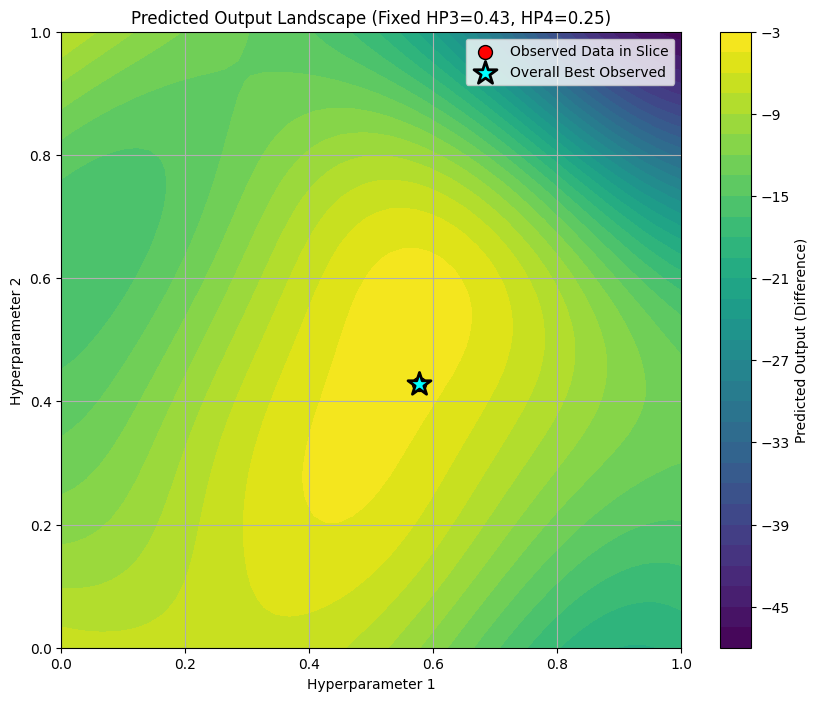

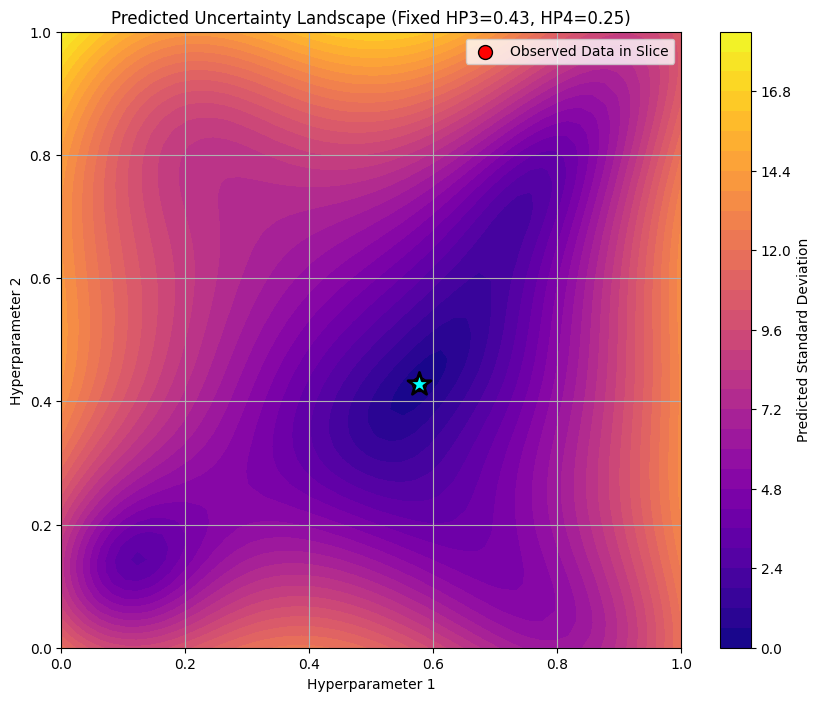

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
# Assuming you have loaded initial_high_inputs, initial_high_outputs, and trained 'gp' from previous steps.

# --- IMPORTANT: Ensure these variables are available from your previous runs ---
# initial_high_inputs = np.load('/content/updated_inputs.npy') # Example if loading from file
# initial_high_outputs = np.load('/content/updated_outputs.npy').flatten() # Example if loading from file
# gp = GaussianProcessRegressor(...) # Your trained GP model from the optimization loop

# Find the overall best observed hyperparameters (closest to 0 output)
best_index = np.argmin(np.abs(initial_high_outputs))
best_hyperparameters = initial_high_inputs[best_index]
best_output_value = initial_high_outputs[best_index] # Keep this for reference


print(f"Visualizing around the best point found: {best_hyperparameters} with output {best_output_value:.4f}")

# --- Choose which two dimensions to fix and which two to vary ---
# Let's fix the 3rd and 4th hyperparameters (indices 2 and 3) at their best values,
# and visualize the landscape across the 1st and 2nd hyperparameters (indices 0 and 1).
fixed_dim1_idx = 2 # Index of the hyperparameter to fix (e.g., x3)
fixed_dim2_idx = 3 # Index of the second hyperparameter to fix (e.g., x4)

fixed_dim1_value = best_hyperparameters[fixed_dim1_idx]
fixed_dim2_value = best_hyperparameters[fixed_dim2_idx]

# --- Create a 2D grid for the varying dimensions (Hyperparameter 1 and 2) ---
num_grid_points = 50 # Density of the grid
hp1_grid = np.linspace(0, 1, num_grid_points) # Range for Hyperparameter 1
hp2_grid = np.linspace(0, 1, num_grid_points) # Range for Hyperparameter 2

HP1_mesh, HP2_mesh = np.meshgrid(hp1_grid, hp2_grid)

# --- Prepare inputs for GP prediction over the 2D slice ---
# The inputs to gp.predict must match the shape of the training data (n_samples, 4 features).
# We'll create a full 4D input array for each point on our 2D grid.
# The fixed dimensions will be filled with their chosen values.
# The varying dimensions (HP1_mesh, HP2_mesh) will be flattened and stacked.

# Initialize a placeholder for the slice inputs
slice_inputs = np.zeros((HP1_mesh.size, initial_high_inputs.shape[1])) # Shape: (num_grid_points*num_grid_points, 4)

# Assign the varying dimensions (HP1, HP2)
slice_inputs[:, 0] = HP1_mesh.ravel()
slice_inputs[:, 1] = HP2_mesh.ravel()

# Assign the fixed dimensions (HP3, HP4)
slice_inputs[:, fixed_dim1_idx] = fixed_dim1_value
slice_inputs[:, fixed_dim2_idx] = fixed_dim2_value

# --- Predict mean output values over this 2D slice using the trained GP ---
predicted_means, predicted_std = gp.predict(slice_inputs, return_std=True)

# Reshape predicted means back to the grid for contour plotting
predicted_means_2d = predicted_means.reshape(num_grid_points, num_grid_points)

# --- Plot the contour map ---
plt.figure(figsize=(10, 8))
contour = plt.contourf(HP1_mesh, HP2_mesh, predicted_means_2d, levels=30, cmap='viridis')
plt.colorbar(contour, label='Predicted Output (Difference)')

# Overlay the observed high-fidelity data points that fall within this slice
# (Optional: Filter points more strictly if you only want very close ones)
observed_slice_mask = np.isclose(initial_high_inputs[:, fixed_dim1_idx], fixed_dim1_value, atol=0.01) & \
                      np.isclose(initial_high_inputs[:, fixed_dim2_idx], fixed_dim2_value, atol=0.01)

plt.scatter(initial_high_inputs[observed_slice_mask, 0],
            initial_high_inputs[observed_slice_mask, 1],
            c='red', marker='o', s=100, edgecolors='k', label='Observed Data in Slice')

# Mark the best overall observed point
plt.scatter(best_hyperparameters[0], best_hyperparameters[1],
            c='cyan', marker='*', s=300, edgecolors='k', linewidth=2, label='Overall Best Observed')


plt.xlabel(f'Hyperparameter 1')
plt.ylabel(f'Hyperparameter 2')
plt.title(f'Predicted Output Landscape (Fixed HP3={fixed_dim1_value:.2f}, HP4={fixed_dim2_value:.2f})')
plt.legend()
plt.grid(True)
plt.show()

# --- Optional: Visualize the uncertainty (standard deviation) ---
# This shows where the model is less confident
predicted_std_2d = predicted_std.reshape(num_grid_points, num_grid_points)
plt.figure(figsize=(10, 8))
contour_std = plt.contourf(HP1_mesh, HP2_mesh, predicted_std_2d, levels=30, cmap='plasma')
plt.colorbar(contour_std, label='Predicted Standard Deviation')
plt.scatter(initial_high_inputs[observed_slice_mask, 0],
            initial_high_inputs[observed_slice_mask, 1],
            c='red', marker='o', s=100, edgecolors='k', label='Observed Data in Slice')
plt.scatter(best_hyperparameters[0], best_hyperparameters[1], c='cyan', marker='*', s=300, edgecolors='k', linewidth=2)
plt.xlabel(f'Hyperparameter 1')
plt.ylabel(f'Hyperparameter 2')
plt.title(f'Predicted Uncertainty Landscape (Fixed HP3={fixed_dim1_value:.2f}, HP4={fixed_dim2_value:.2f})')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt # Assuming you might want to visualize results
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# --- IMPORTANT: Ensure these variables are available from your previous runs ---
# initial_high_inputs = np.load('/content/updated_inputs.npy') # Example if loading from file
# initial_high_outputs = np.load('/content/updated_outputs.npy').flatten() # Example if loading from file
# gp = GaussianProcessRegressor(...) # Your trained GP model from the optimization loop
# best_hyperparameters = initial_high_inputs[np.argmin(np.abs(initial_high_outputs))] # Your best found parameters

# --- Predict at the best observed point ---
# gp.predict expects a 2D array, even for a single sample
best_prediction, best_std = gp.predict(best_hyperparameters.reshape(1, -1), return_std=True)

print(f"Prediction at best observed hyperparameters {best_hyperparameters}:")
print(f"  Mean: {best_prediction[0]:.4f}, Std Dev: {best_std[0]:.4f}")

# --- Exploit (Predict around the best parameters) ---
# Let's generate a few points slightly perturbed around the best_hyperparameters
# This allows us to see the GP's predicted landscape in that immediate vicinity.

num_perturbations = 5
perturbation_scale = 0.01 # A small value, e.g., 1% of the [0,1] range

# Generate random perturbations
perturbations = np.random.uniform(-perturbation_scale, perturbation_scale,
                                  size=(num_perturbations, best_hyperparameters.shape[0]))

# Create new query points by adding perturbations to the best_hyperparameters
# Ensure these new points stay within the [0, 1] bounds
exploration_points = np.clip(best_hyperparameters + perturbations, 0, 1)

print(f"\nExploiting: Predicting around the best hyperparameters (perturbation scale: {perturbation_scale}):")
for i, point in enumerate(exploration_points):
    predicted_mean, predicted_std = gp.predict(point.reshape(1, -1), return_std=True)
    print(f"  Query {i+1}: {point}, Predicted Mean: {predicted_mean[0]:.4f}, Predicted Std Dev: {predicted_std[0]:.4f}")


# --- Extrapolation Example (Predicting outside observed range, be cautious!) ---
# This is just an illustrative example. Use with caution for real decisions.
# Let's say you want to predict beyond the typical range of one hyperparameter.
# For example, if 'best_hyperparameters[0]' was 0.8, you might try 1.1 (outside [0,1])
# or a point where values are at 1.5, etc.

# Define an extrapolation point (e.g., slightly outside the [0,1] range for demonstration)
# This assumes your domain goes beyond [0,1] or you want to see GP behavior there.
extrapolation_point = np.array([1.1, 0.5, 0.5, 0.5]) # Example: first HP is > 1

# Check if the point is indeed outside the initial observed range for any dimension
# This is a simple check, your 'spatial_bounds' are [0,1]
is_extrapolating = np.any(extrapolation_point < 0) or np.any(extrapolation_point > 1)

if is_extrapolating:
    extrapolated_mean, extrapolated_std = gp.predict(extrapolation_point.reshape(1, -1), return_std=True)
    print(f"\nExtrapolation (Caution!): Predicting at {extrapolation_point}:")
    print(f"  Predicted Mean: {extrapolated_mean[0]:.4f}, Predicted Std Dev: {extrapolated_std[0]:.4f}")
    print("  Note: Uncertainty (Std Dev) is typically much higher during extrapolation.")
else:
    print("\nExtrapolation example skipped as point is within [0,1] range.")

Prediction at best observed hyperparameters [0.57776561 0.42877174 0.42582587 0.24900741]:
  Mean: -4.0107, Std Dev: 0.0000

Exploiting: Predicting around the best hyperparameters (perturbation scale: 0.01):
  Query 1: [0.56890227 0.42320821 0.42223238 0.25028702], Predicted Mean: -3.9155, Predicted Std Dev: 0.1533
  Query 2: [0.58153332 0.43452503 0.43512268 0.24055891], Predicted Mean: -4.3828, Predicted Std Dev: 0.3847
  Query 3: [0.572887   0.4249684  0.41847389 0.25319526], Predicted Mean: -3.8057, Predicted Std Dev: 0.2386
  Query 4: [0.57460288 0.42816079 0.41922991 0.24607957], Predicted Mean: -3.9824, Predicted Std Dev: 0.0709
  Query 5: [0.5843164  0.43793903 0.43157307 0.25623372], Predicted Mean: -3.9014, Predicted Std Dev: 0.1043

Extrapolation (Caution!): Predicting at [1.1 0.5 0.5 0.5]:
  Predicted Mean: -23.2930, Predicted Std Dev: 11.3559
  Note: Uncertainty (Std Dev) is typically much higher during extrapolation.


In [ ]:
import numpy as np
from skopt import dummy_minimize
from skopt.space import Real # For defining search bounds (same as your spatial_bounds)
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# Assuming your 'gp' model is already trained from the previous Bayesian Optimization loop
# (i.e., gp.fit(initial_high_inputs, initial_high_outputs) has been run)

# --- Define the target output ---
target_output = 2.0

# --- Define a new objective function for finding inputs that yield the target_output ---
def find_target_output_objective(x_candidate, gp_model, target_val):
    """
    Objective function to minimize the absolute difference between GP prediction and target value.
    """
    # Ensure x_candidate is 2D
    if x_candidate.ndim == 1:
        x_candidate = x_candidate.reshape(1, -1)

    mu, sigma = gp_model.predict(x_candidate, return_std=True)

    # We want to minimize the absolute difference
    abs_diff = np.abs(mu.item() - target_val)
    return abs_diff

# --- Define search space for the hyperparameters (same as your spatial_bounds) ---
# Assuming 4 input dimensions, each from 0 to 1
search_space_for_target = [(0, 1), (0, 1), (0, 1), (0, 1)]

# --- Find the best input(s) that result in the target output ---
print(f"\nSearching for inputs that result in an output of {target_output}...")

# We'll run dummy_minimize to find the minimum of our new objective function.
# The initial point (x0) can be random or a guess.
# For simplicity, we'll let dummy_minimize explore randomly within the bounds.
# Increase n_calls for a better search.
result_target = dummy_minimize(lambda x: find_target_output_objective(np.array(x), gp, target_output),
                               search_space_for_target,
                               n_calls=500, # Increased n_calls for a better search
                               random_state=42) # For reproducibility

predicted_input_for_target = np.array(result_target.x)
predicted_output_at_input = gp.predict(predicted_input_for_target.reshape(1, -1)).item() # Predict the output at this found input

print(f"Suggested Input for Output {target_output}: {predicted_input_for_target}")
print(f"Predicted Output at this Input: {predicted_output_at_input}")
print(f"Absolute difference from target: {np.abs(predicted_output_at_input - target_output):.4f}")

# Optional: You can run this multiple times or with different random_states
# to find several candidate inputs for the desired output.


Searching for inputs that result in an output of 2.0...
Suggested Input for Output 2.0: [0 1 0 0]
Predicted Output at this Input: 19.932558059692383
Absolute difference from target: 17.9326


In [ ]:
# --- IMPORTANT: Run this cell to ensure scikit-learn and scikit-optimize are installed. ---
# This will try to install scikit-learn and its necessary dependencies.

# Ensure scikit-learn is installed.
# Using --upgrade --no-deps ensures it only updates itself and doesn't try to
# mess with numpy/scipy versions that might be held by other Colab packages.
!pip install --upgrade --no-deps scikit-learn

# Ensure scikit-optimize is installed.
!pip install scikit-optimize

# --- After running this cell, proceed to run your main code cell. ---
# You typically do NOT need to restart the runtime for this unless the error persists.

In [ ]:
import numpy as np

# Your best identified hyperparameters
best_hyperparameters = np.array([0.57776561, 0.42877174, 0.42582587, 0.24900741])

# Define a standard deviation for the noise (jitter).
# This controls how far away from the best point the new queries will be.
# Adjust this value based on how "fine-grained" you want your search to be.
# A smaller value means queries closer to the best point.
# A larger value means queries more spread out around the best point.
noise_std_dev = 0.05 # Example: 5% of the input range, adjust as needed

# Number of new queries to generate
num_new_queries = 4

# Generate 4 new queries by adding random Gaussian noise
# We use np.random.normal to generate noise with a mean of 0 and a specified std_dev
# We then add this noise to the best_hyperparameters.
# np.clip is used to ensure the new queries stay within the [0, 1] bounds.
new_queries = []
for _ in range(num_new_queries):
    # Generate noise for 4 dimensions
    noise = np.random.normal(0, noise_std_dev, size=best_hyperparameters.shape)

    # Add noise to the best hyperparameters
    new_query = best_hyperparameters + noise

    # Clip the values to ensure they stay within [0, 1]
    new_query = np.clip(new_query, 0, 1)

    new_queries.append(new_query)

# Convert the list of queries to a NumPy array for easier handling
new_queries = np.array(new_queries)

# Print the generated queries
print("Generated queries for exploitation:")
for i, query in enumerate(new_queries):
    print(f"Query {i+1}: {query}")

# Optional: Format the queries for your specific display format
# formatted_queries = []
# for query in new_queries:
#     formatted_query_str = "-".join([f"0.{int(val * 1e6):06d}" for val in query])
#     formatted_queries.append(formatted_query_str)
# print("\nFormatted Queries:")
# for i, query_str in enumerate(formatted_queries):
#     print(f"Query {i+1}: {query_str}")

Generated queries for exploitation:
Query 1: [0.58092872 0.44263649 0.45710202 0.27581699]
Query 2: [0.59107543 0.51395465 0.33546106 0.21185429]
Query 3: [0.5283023  0.37646335 0.41399936 0.23195458]
Query 4: [0.53480354 0.53153048 0.45688002 0.18466255]


In [ ]:
import numpy as np

# Load existing data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# New data point
new_input = np.array([0.580928, 0.442636, 0.457102, 0.275816])
new_output = np.float64(-4.339586287400596)

# Add new data to existing arrays
updated_inputs = np.vstack([updated_inputs, new_input])
updated_outputs = np.append(updated_outputs, new_output)

# Save the updated arrays
np.save('/content/updated_inputs.npy', updated_inputs)
np.save('/content/updated_outputs.npy', updated_outputs)

print("Data appended and saved successfully!")

Data appended and saved successfully!


In [ ]:
import numpy as np

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the updated data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)


Updated Inputs:
 [[0.89698105 0.72562797 0.17540431 0.70169437]
 [0.8893564  0.49958786 0.53926886 0.50878344]
 [0.25094624 0.03369313 0.14538002 0.49493242]
 [0.34696206 0.0062504  0.76056361 0.61302356]
 [0.12487118 0.12977019 0.38440048 0.2870761 ]
 [0.80130271 0.50023109 0.70664456 0.19510284]
 [0.24770826 0.06044543 0.04218635 0.44132425]
 [0.74670224 0.7570915  0.36935306 0.20656628]
 [0.40066503 0.07257425 0.88676825 0.24384229]
 [0.6260706  0.58675126 0.43880578 0.77885769]
 [0.95713529 0.59764438 0.76611385 0.77620991]
 [0.73281243 0.14524998 0.47681272 0.13336573]
 [0.65511548 0.07239183 0.68715175 0.08151656]
 [0.21973443 0.83203134 0.48286416 0.08256923]
 [0.48859419 0.2119651  0.93917791 0.37619173]
 [0.16713049 0.87655456 0.21723954 0.95980098]
 [0.21691119 0.16608583 0.24137226 0.77006248]
 [0.38748784 0.80453226 0.75179548 0.72382744]
 [0.98562189 0.66693268 0.15678328 0.8565348 ]
 [0.03782483 0.66485335 0.16198218 0.25392378]
 [0.68348638 0.9027701  0.33541983 0.999482

In [ ]:
!pip install scikit-optimize

Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/commands/install.py", line 324, in run
    session = self.get_default_session(options)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/cli/index_command.py", line 71, in get_default_session
    self._session = self.enter_context(self._build_session(options))
                                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/cli/index_command.py", line 100, in _build_session
    session = PipSession(
              ^^^^^^^^^

In [ ]:
!pip install scikit-optimize
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from skopt.acquisition import gaussian_lcb  # Import gaussian_lcb
from skopt import dummy_minimize
from skopt.space import Real

# Load the updated data (Assuming updated_inputs.npy and updated_outputs.npy exist)
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Define the kernel for the Gaussian Process
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))

# Create the Gaussian Process Regressor
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)

# Define the bounds for the hyperparameters using Real objects
# Assuming your hyperparameters are between 0 and 1
bounds = [Real(0, 1), Real(0, 1), Real(0, 1), Real(0, 1)]

# Function to find the next query using Lower Confidence Bound acquisition function
def next_query_lcb(gpr, bounds):
  """
  Finds the next query point using Lower Confidence Bound.

  Args:
    gpr: The fitted Gaussian Process Regressor.
    bounds: The bounds for the hyperparameters.

  Returns:
    The next query point as a numpy array.
  """

  # Use dummy_minimize to find the point that minimizes the LCB acquisition function
  # Reshape x to a 2D array with one row using np.atleast_2d
  # Access the first element of the gaussian_lcb output to get a scalar
  res = dummy_minimize(lambda x: gaussian_lcb(np.atleast_2d(x), gpr, kappa=1.0)[0],  # Minimize LCB (kappa can be adjusted)
                      bounds, n_calls=200) # You can adjust n_calls and the optimizer
  return res.x

# Fit the GPR model to the existing data
gpr.fit(updated_inputs, updated_outputs)

# Get the next query using LCB
next_query_point_lcb = next_query_lcb(gpr, bounds)

# Print the suggested next query
print("Suggested Next Query (LCB):", next_query_point_lcb)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.1 MB/s eta 0:00:00
Suggested Next Query (LCB): [0.8154698912908841, 0.8381179604121087, 0.809177168138684, 0.9722403075159427]


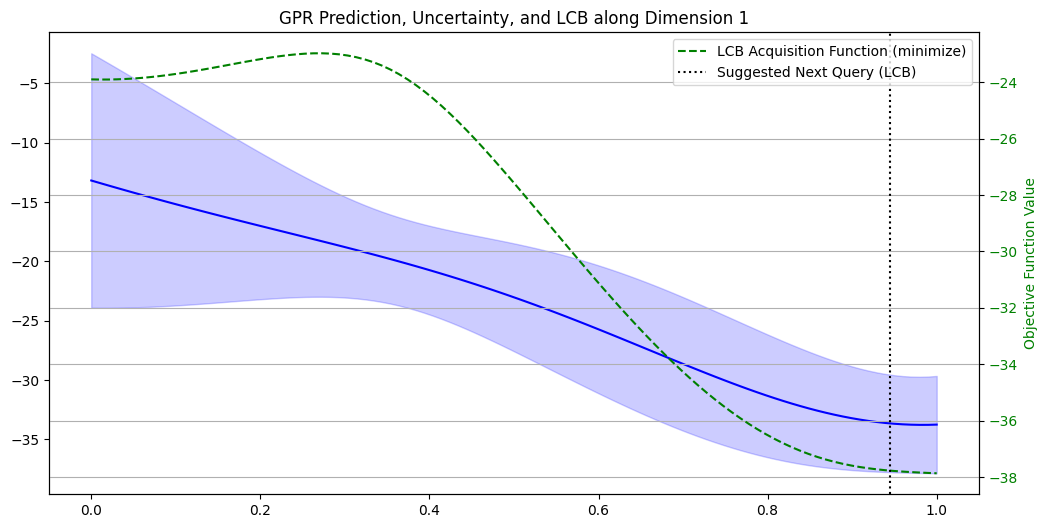

In [ ]:
# Get the suggested next query point from the previous step
# (Assuming you have run the cell that calculates next_query_point_lcb)
# If not, you would need to run that cell first or recalculate it here.
# For this visualization, we'll assume next_query_point_lcb is available.
# If not, you can replace this with a point of interest, e.g., updated_inputs[np.argmin(updated_outputs)]
# Or, run the previous cell to get next_query_point_lcb
bounds = [Real(0, 1), Real(0, 1), Real(0, 1), Real(0, 1)]
def next_query_lcb(gpr, bounds):
    res = dummy_minimize(lambda x: gaussian_lcb(np.atleast_2d(x), gpr, kappa=1.0)[0], bounds, n_calls=200)
    return res.x
from skopt import dummy_minimize
from skopt.space import Real
next_query_point_lcb = np.array(next_query_lcb(gpr, bounds)) # Recalculate for safety in this block and convert to numpy array


# --- Visualization ---

# Choose which hyperparameter dimension to visualize (0-indexed)
# Let's visualize the first dimension (index 0)
dim_to_visualize = 0
fixed_dims = [i for i in range(updated_inputs.shape[1]) if i != dim_to_visualize]

# Create a range of values for the chosen dimension
x_plot = np.linspace(0, 1, 100).reshape(-1, 1)

# Create a grid of points for prediction by fixing other dimensions
# We'll fix the other dimensions to the values of the suggested next_query_point_lcb
# This creates a 1D slice through the space
X_predict = np.tile(next_query_point_lcb, (100, 1))
X_predict[:, dim_to_visualize] = x_plot.flatten()


# Predict the mean and standard deviation using the GPR
y_mean, y_std = gpr.predict(X_predict, return_std=True)

# Calculate the LCB acquisition function values for these points
# LCB = mu - kappa * sigma. We use kappa=1.0 as in the next_query_lcb function
# Note: For minimization, we want to find the minimum of LCB, which corresponds
# to maximizing -LCB. The acquisition function usually provided in libraries
# like skopt is designed for maximization (higher is better).
# Let's calculate LCB directly: LCB = y_mean - 1.0 * y_std
# Or use skopt's gaussian_lcb, which is for minimization (lower is better).
# skopt's gaussian_lcb returns the value to be MINIMIZED.
# Let's use skopt's gaussian_lcb to be consistent with the optimization.
lcb_values = gaussian_lcb(X_predict, gpr, kappa=1.0)


plt.figure(figsize=(12, 6))

# Plot the predicted mean
plt.plot(x_plot, y_mean, 'b-', label='Predicted Mean')

# Plot the confidence interval (uncertainty)
plt.fill_between(x_plot.flatten(), y_mean - y_std, y_mean + y_std, alpha=0.2, color='blue', label='95% Confidence')

# Plot the observed data points along this slice (or near it)
# Finding points exactly on the slice is unlikely in high dimensions.
# Let's find points close to this slice. We can be approximate here for visualization.
# A simple way is to just plot all points and hope some are visible, or
# filter points where fixed dimensions are close to the slice values.
# For simplicity in this visualization, let's plot the actual observed points
# projected onto this 1D slice.
# Filter points based on proximity to the slice's fixed dimensions
tolerance = 0.05 # Adjust tolerance as needed
mask = np.all(np.abs(updated_inputs[:, fixed_dims] - next_query_point_lcb[fixed_dims]) < tolerance, axis=1)
observed_x_slice = updated_inputs[mask, dim_to_visualize]
observed_y_slice = updated_outputs[mask]

plt.scatter(observed_x_slice, observed_y_slice, c='red', label='Observed Data', zorder=5)


# Plot the LCB acquisition function (minimize this)
# We scale it to fit on the same plot, or use a secondary y-axis
# Let's plot it on the primary y-axis for simplicity, scaled/shifted if needed.
# To show "better is lower", we'll plot LCB directly.
ax2 = plt.gca().twinx() # Use a secondary y-axis for the acquisition function
ax2.plot(x_plot, lcb_values, 'g--', label='LCB Acquisition Function (minimize)')
ax2.set_ylabel('LCB Value', color='green')
ax2.tick_params(axis='y', labelcolor='green')


# Highlight the suggested next query point on the slice
plt.axvline(x=next_query_point_lcb[dim_to_visualize], color='k', linestyle=':', label='Suggested Next Query (LCB)')


plt.xlabel(f'Hyperparameter Dimension {dim_to_visualize+1}')
plt.ylabel('Objective Function Value')
plt.title(f'GPR Prediction, Uncertainty, and LCB along Dimension {dim_to_visualize+1}')
plt.legend(loc='upper left') # Adjust legend location as needed
ax2.legend(loc='upper right') # Legend for the secondary axis
plt.grid(True)
plt.show()

# You might want to try visualizing different dimensions (change dim_to_visualize)
# or slices through different fixed points.

In [ ]:
!pip install scikit-optimize
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from skopt.acquisition import gaussian_lcb  # Import gaussian_lcb
from skopt import dummy_minimize
from skopt.space import Real

# Load the updated data (Assuming updated_inputs.npy and updated_outputs.npy exist)
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Define the kernel for the Gaussian Process
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))

# Create the Gaussian Process Regressor
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)

# Define the bounds for the hyperparameters using Real objects
# Assuming your hyperparameters are between 0 and 1
bounds = [Real(0, 1), Real(0, 1), Real(0, 1), Real(0, 1)]

# Function to find the next query using Lower Confidence Bound acquisition function
def next_query_lcb(gpr, bounds):
  """
  Finds the next query point using Lower Confidence Bound.

  Args:
    gpr: The fitted Gaussian Process Regressor.
    bounds: The bounds for the hyperparameters.

  Returns:
    The next query point as a numpy array.
  """

  # Use dummy_minimize to find the point that minimizes the LCB acquisition function
  # Reshape x to a 2D array with one row using np.atleast_2d
  # Access the first element of the gaussian_lcb output to get a scalar
  res = dummy_minimize(lambda x: gaussian_lcb(np.atleast_2d(x), gpr, kappa=1.0)[0],  # Minimize LCB (kappa can be adjusted)
                      bounds, n_calls=200) # You can adjust n_calls and the optimizer
  return res.x

# Fit the GPR model to the existing data
gpr.fit(updated_inputs, updated_outputs)

# Get the next query using LCB
next_query_point_lcb = next_query_lcb(gpr, bounds)

# Print the suggested next query
print("Suggested Next Query (LCB):", next_query_point_lcb)

Suggested Next Query (LCB): [0.9395494943748393, 0.6769728868173324, 0.938159889632919, 0.9776839015435353]


Suggested Next Query (LCB): [0.7237871  0.96642492 0.99553581 0.86614059]


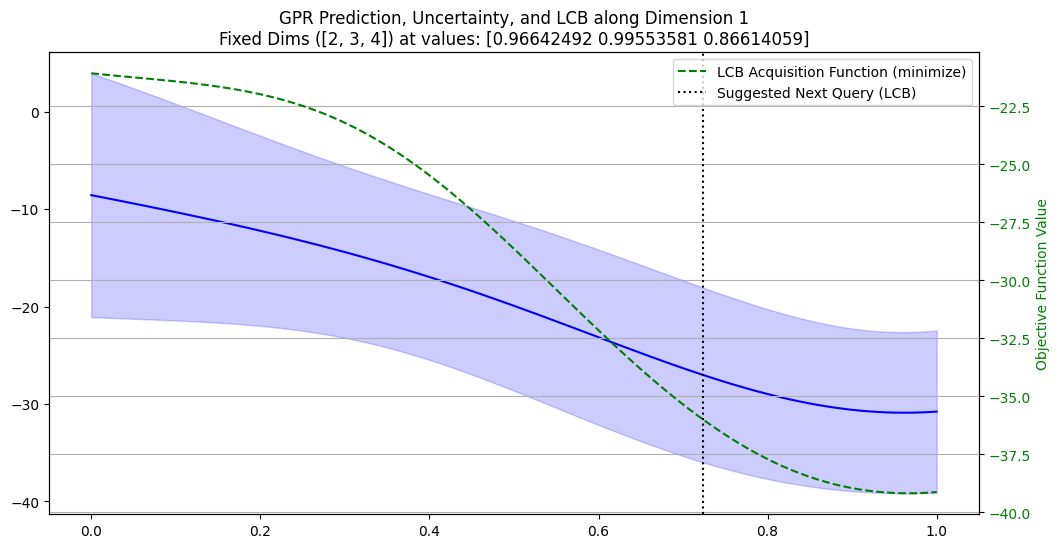

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from skopt.acquisition import gaussian_lcb  # Import gaussian_lcb
from skopt import dummy_minimize # Import dummy_minimize
from skopt.space import Real # Import Real

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Define the kernel for the Gaussian Process
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))

# Create the Gaussian Process Regressor
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)

# Fit the GPR model to the existing data
gpr.fit(updated_inputs, updated_outputs)

# Define the bounds for the hyperparameters
bounds = [Real(0, 1), Real(0, 1), Real(0, 1), Real(0, 1)]

# Function to find the next query using Lower Confidence Bound acquisition function
# (Copied from the previous cell for completeness in this visualization block)
def next_query_lcb(gpr, bounds):
    res = dummy_minimize(lambda x: gaussian_lcb(np.atleast_2d(x), gpr, kappa=1.0)[0], bounds, n_calls=200)
    return np.array(res.x) # Ensure it's a numpy array

# Get the suggested next query point
next_query_point_lcb = next_query_lcb(gpr, bounds)
print(f"Suggested Next Query (LCB): {next_query_point_lcb}")


# --- Visualization of 1D Slice ---

# Choose which hyperparameter dimension to visualize (0-indexed)
dim_to_visualize = 0 # You can change this to 1, 2, or 3

# Get the indices of the dimensions to fix
fixed_dims = [i for i in range(updated_inputs.shape[1]) if i != dim_to_visualize]

# Create a range of values for the chosen dimension
x_plot = np.linspace(0, 1, 100).reshape(-1, 1)

# Create a grid of points for prediction by fixing other dimensions
# We'll fix the other dimensions to the values of the suggested next_query_point_lcb
# This creates a 1D slice through the space
X_predict = np.tile(next_query_point_lcb, (100, 1))
X_predict[:, dim_to_visualize] = x_plot.flatten()

# Predict the mean and standard deviation using the GPR
y_mean, y_std = gpr.predict(X_predict, return_std=True)

# Calculate the LCB acquisition function values for these points
# skopt's gaussian_lcb is for minimization (lower is better).
lcb_values = gaussian_lcb(X_predict, gpr, kappa=1.0)


plt.figure(figsize=(12, 6))

# Plot the predicted mean
plt.plot(x_plot, y_mean, 'b-', label='Predicted Mean')

# Plot the confidence interval (uncertainty)
plt.fill_between(x_plot.flatten(), y_mean - y_std, y_mean + y_std, alpha=0.2, color='blue', label='95% Confidence')

# Plot the observed data points along this slice (or near it)
# Filter points based on proximity to the slice's fixed dimensions
tolerance = 0.05 # Adjust tolerance as needed
mask = np.all(np.abs(updated_inputs[:, fixed_dims] - next_query_point_lcb[fixed_dims]) < tolerance, axis=1)
observed_x_slice = updated_inputs[mask, dim_to_visualize]
observed_y_slice = updated_outputs[mask]

plt.scatter(observed_x_slice, observed_y_slice, c='red', label='Observed Data (near slice)', zorder=5)

# Use a secondary y-axis for the acquisition function
ax2 = plt.gca().twinx()
# Plot the LCB acquisition function (minimize this)
ax2.plot(x_plot, lcb_values, 'g--', label='LCB Acquisition Function (minimize)')
ax2.set_ylabel('LCB Value', color='green')
ax2.tick_params(axis='y', labelcolor='green')

# Highlight the suggested next query point on the slice
plt.axvline(x=next_query_point_lcb[dim_to_visualize], color='k', linestyle=':', label='Suggested Next Query (LCB)')

plt.xlabel(f'Hyperparameter Dimension {dim_to_visualize+1}')
plt.ylabel('Objective Function Value')
plt.title(f'GPR Prediction, Uncertainty, and LCB along Dimension {dim_to_visualize+1}\n'
          f'Fixed Dims ({[d+1 for d in fixed_dims]}) at values: {next_query_point_lcb[fixed_dims]}')
plt.legend(loc='upper left') # Adjust legend location as needed
ax2.legend(loc='upper right') # Legend for the secondary axis
plt.grid(True)
plt.show()

# You can repeat this visualization for different values of dim_to_visualize (0, 1, 2, 3)
# to see the slice along each hyperparameter dimension.

# --- Example of 2D Slice (Conceptual) ---
# This is more complex and requires generating a 2D grid for two dimensions
# while fixing the other two.

# # Choose two dimensions to visualize (e.g., 0 and 1)
# dim1_to_visualize = 0
# dim2_to_visualize = 1
# fixed_dims_2d = [i for i in range(updated_inputs.shape[1]) if i not in [dim1_to_visualize, dim2_to_visualize]]

# # Create a 2D grid for these two dimensions
# x1_plot = np.linspace(0, 1, 50)
# x2_plot = np.linspace(0, 1, 50)
# X1_grid, X2_grid = np.meshgrid(x1_plot, x2_plot)

# # Create prediction points
# X_predict_2d = np.tile(next_query_point_lcb, (X1_grid.size, 1))
# X_predict_2d[:, dim1_to_visualize] = X1_grid.flatten()
# X_predict_2d[:, dim2_to_visualize] = X2_grid.flatten()

# # Predict mean and LCB
# y_mean_2d, _ = gpr.predict(X_predict_2d, return_std=True)
# lcb_values_2d = gaussian_lcb(X_predict_2d, gpr, kappa=1.0)

# # Reshape for contour plots
# y_mean_2d = y_mean_2d.reshape(X1_grid.shape)
# lcb_values_2d = lcb_values_2d.reshape(X1_grid.shape)

# # Plotting (requires a contour plot)
# plt.figure(figsize=(10, 8))
# cp = plt.contourf(X1_grid, X2_grid, y_mean_2d, levels=20, cmap='viridis')
# plt.colorbar(cp, label='Predicted Mean')
# plt.scatter(updated_inputs[:, dim1_to_visualize], updated_inputs[:, dim2_to_visualize], c=updated_outputs, edgecolors='k', label='Observed Data')
# plt.xlabel(f'Hyperparameter Dimension {dim1_to_visualize+1}')
# plt.ylabel(f'Hyperparameter Dimension {dim2_to_visualize+1}')
# plt.title(f'2D Slice of Predicted Mean (Dims {dim1_to_visualize+1} vs {dim2_to_visualize+1})')
# plt.legend()
# plt.show()

# # You would repeat the contour plot for LCB values to visualize the acquisition function landscape

In [ ]:
!pip install scikit-optimize matplotlib

import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from skopt.acquisition import gaussian_lcb
from skopt import dummy_minimize
from skopt.space import Real

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Define the kernel for the Gaussian Process
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))

# Create the Gaussian Process Regressor
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)

# Fit the GPR model to the existing data
gpr.fit(updated_inputs, updated_outputs)

# Define the bounds for the hyperparameters
bounds = [Real(0, 1), Real(0, 1), Real(0, 1), Real(0, 1)]

# Function to find the next query using Lower Confidence Bound acquisition function
def next_query_lcb(gpr, bounds):
    res = dummy_minimize(lambda x: gaussian_lcb(np.atleast_2d(x), gpr, kappa=1.0)[0], bounds, n_calls=200)
    return np.array(res.x) # Ensure it's a numpy array

# Get the suggested next query point (we'll use this to fix other dimensions)
next_query_point_lcb = next_query_lcb(gpr, bounds)
print(f"Suggested Next Query (LCB): {next_query_point_lcb}")


# --- Visualization of 2D Slice ---

# Choose which two hyperparameter dimensions to visualize (0-indexed)
dim1_to_visualize = 0 # First dimension for the 2D plot
dim2_to_visualize = 1 # Second dimension for the 2D plot

# Get the indices of the dimensions to fix
fixed_dims_2d = [i for i in range(updated_inputs.shape[1]) if i not in [dim1_to_visualize, dim2_to_visualize]]

# Get the values to fix the other dimensions at (using the suggested next query point)
fixed_values = next_query_point_lcb[fixed_dims_2d]

# Create a 2D grid for the two chosen dimensions
n_grid_points = 50 # Number of points along each dimension
x1_plot = np.linspace(0, 1, n_grid_points)
x2_plot = np.linspace(0, 1, n_grid_points)
X1_grid, X2_grid = np.meshgrid(x1_plot, x2_plot)

# Create prediction points by combining the grid with the fixed values
X_predict_2d = np.zeros((n_grid_points * n_grid_points, updated_inputs.shape[1]))

# Populate the columns corresponding to the visualized dimensions
X_predict_2d[:, dim1_to_visualize] = X1_grid.flatten()
X_predict_2d[:, dim2_to_visualize] = X2_grid.flatten()

# Populate the columns corresponding to the fixed dimensions
for i, fixed_dim_index in enumerate(fixed_dims_2d):
    X_predict_2d[:, fixed_dim_index] = fixed_values[i]

# Predict the mean and standard deviation using the GPR
y_mean_2d, y_std_2d = gpr.predict(X_predict_2d, return_std=True)

# Calculate the LCB acquisition function values for these points
lcb_values_2d = gaussian_lcb(X_predict_2d, gpr, kappa=1.0)

# Reshape the predictions and LCB values back to the

Suggested Next Query (LCB): [0.80395442 0.98315435 0.94071306 0.85264321]


In [ ]:
import numpy as np

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the updated data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

Updated Inputs:
 [[0.89698105 0.72562797 0.17540431 0.70169437]
 [0.8893564  0.49958786 0.53926886 0.50878344]
 [0.25094624 0.03369313 0.14538002 0.49493242]
 [0.34696206 0.0062504  0.76056361 0.61302356]
 [0.12487118 0.12977019 0.38440048 0.2870761 ]
 [0.80130271 0.50023109 0.70664456 0.19510284]
 [0.24770826 0.06044543 0.04218635 0.44132425]
 [0.74670224 0.7570915  0.36935306 0.20656628]
 [0.40066503 0.07257425 0.88676825 0.24384229]
 [0.6260706  0.58675126 0.43880578 0.77885769]
 [0.95713529 0.59764438 0.76611385 0.77620991]
 [0.73281243 0.14524998 0.47681272 0.13336573]
 [0.65511548 0.07239183 0.68715175 0.08151656]
 [0.21973443 0.83203134 0.48286416 0.08256923]
 [0.48859419 0.2119651  0.93917791 0.37619173]
 [0.16713049 0.87655456 0.21723954 0.95980098]
 [0.21691119 0.16608583 0.24137226 0.77006248]
 [0.38748784 0.80453226 0.75179548 0.72382744]
 [0.98562189 0.66693268 0.15678328 0.8565348 ]
 [0.03782483 0.66485335 0.16198218 0.25392378]
 [0.68348638 0.9027701  0.33541983 0.999482

In [ ]:
import numpy as np

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Find the indices of the smallest absolute outputs (closest to zero)
# argsort returns the indices that would sort the array in ascending order
# We use np.abs() to sort by the absolute value
sorted_indices = np.argsort(np.abs(updated_outputs))

# Get the indices of the top 5 smallest absolute outputs
top_5_indices = sorted_indices[:5]

# Get the input combinations corresponding to the top 5 smallest outputs
best_inputs = updated_inputs[top_5_indices]

# Print the best input combinations and their corresponding outputs
print("Top 5 Best Input Combinations (based on smallest absolute output):")
for i, input_combination in enumerate(best_inputs):
    output_value = updated_outputs[top_5_indices[i]]
    print(f"Input Combination {i+1}: {input_combination}, Output: {output_value}")

Top 5 Best Input Combinations (based on smallest absolute output):
Input Combination 1: [0.57776561 0.42877174 0.42582587 0.24900741], Output: -4.025542281908162
Input Combination 2: [0.55688  0.402467 0.4167   0.2356  ], Output: -4.197386925326807
Input Combination 3: [0.580928 0.442636 0.457102 0.275816], Output: -4.339586287400596
Input Combination 4: [0.565116 0.422936 0.338553 0.205396], Output: -5.065082308923291
Input Combination 5: [0.571673 0.35481  0.35332  0.15263 ], Output: -5.969804799852032


In [ ]:
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 2.5 MB/s eta 0:00:00


In [ ]:
!pip install scikit-optimize
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from skopt.acquisition import gaussian_ei
from skopt import dummy_minimize
from skopt.space import Real

# --- 1. Load Initial Data ---
# Load the initial data or continue with your updated data
try:
    updated_inputs = np.load('/content/updated_inputs.npy')
    updated_outputs = np.load('/content/updated_outputs.npy')
    print("Loaded updated data.")
except FileNotFoundError:
    # If updated data not found, load initial data
    initial_inputs = np.load('/content/initial_inputs.npy')
    initial_outputs = np.load('/content/initial_outputs.npy')
    updated_inputs = initial_inputs
    updated_outputs = initial_outputs
    print("Loaded initial data.")


# --- 2. Define the Objective Function ---
def objective_function(hyperparameters):
    """
    This function represents your machine learning model and returns the
    difference between the expensive calculation and the model's prediction.

    Args:
        hyperparameters: A list or array of 4 hyperparameter values.

    Returns:
        The difference between the expensive calculation and the model's prediction.
    """
    # !!! IMPORTANT: Replace this with your actual model evaluation logic !!!
    # Simulate the "expensive calculation" and your fast model's prediction
    # For demonstration, let's use a simple function with some noise and local optima
    # This is just a placeholder - YOU NEED TO REPLACE THIS
    hyperparameters = np.array(hyperparameters) # Ensure it's a numpy array
    simulated_expensive_output = np.sum(np.sin(hyperparameters * 10)) + np.random.randn() * 0.1
    simulated_model_prediction = np.sum(hyperparameters**2)
    difference = simulated_expensive_output - simulated_model_prediction

    return difference # We want to minimize the absolute difference, so we can return the difference


# --- 3. Set up Bayesian Optimization Components ---
# Define the kernel for the Gaussian Process
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))

# Create the Gaussian Process Regressor
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)

# Define the bounds for the hyperparameters using Real objects (assuming 0 to 1)
bounds = [Real(0, 1), Real(0, 1), Real(0, 1), Real(0, 1)]

# Function to find the next query using Expected Improvement acquisition function
def find_next_query(gpr, bounds, current_best_output):
  """
  Finds the next query point by maximizing the Expected Improvement.

  Args:
    gpr: The fitted Gaussian Process Regressor.
    bounds: The bounds for the hyperparameters.
    current_best_output: The current minimum observed output value.

  Returns:
    The next query point as a numpy array.
  """
  # We minimize the negative Expected Improvement to maximize EI
  res = dummy_minimize(lambda x: -gaussian_ei(np.atleast_2d(x), gpr, current_best_output)[0],
                      bounds, n_calls=200) # You can adjust n_calls for the optimizer
  return res.x

# --- 4. Run the Bayesian Optimization Loop ---
num_iterations = 20 # Set the number of BO iterations

print("\nStarting Bayesian Optimization Loop...")

for i in range(num_iterations):
    print(f"\nIteration {i+1}/{num_iterations}")

    # Fit the GPR model to the existing data
    gpr.fit(updated_inputs, updated_outputs)

    # Get the current best observed output
    current_best_output = np.min(updated_outputs)

    # Get the next query point recommended by the acquisition function
    next_query_point = find_next_query(gpr, bounds, current_best_output)

    # Evaluate the objective function at the next query point
    # This is where you would run your machine learning model and expensive calculation
    new_output = objective_function(next_query_point)
    print(f"Evaluating query: {next_query_point}, Result: {new_output}")

    # Add the new data point to the existing data
    updated_inputs = np.vstack([updated_inputs, next_query_point])
    updated_outputs = np.append(updated_outputs, new_output)

    # --- Optional: Save updated data after each iteration ---
    np.save('/content/updated_inputs.npy', updated_inputs)
    np.save('/content/updated_outputs.npy', updated_outputs)
    print("Updated data saved.")

# --- 5. Print Final Results ---
print("\nBayesian Optimization Finished.")

# Find the best hyperparameters and output from all evaluations
best_index = np.argmin(np.abs(updated_outputs)) # Find the index with the smallest absolute output
best_hyperparameters = updated_inputs[best_index]
best_output = updated_outputs[best_index]

print("\nBest Hyperparameters Found:")
print(best_hyperparameters)
print("Corresponding Output (difference):", best_output)

# Print the top 5 best input combinations from the final dataset
print("\nTop 5 Best Input Combinations (based on smallest absolute output) after BO:")
sorted_indices = np.argsort(np.abs(updated_outputs))
top_5_indices = sorted_indices[:5]
best_inputs_final = updated_inputs[top_5_indices]
for i, input_combination in enumerate(best_inputs_final):
    output_value = updated_outputs[top_5_indices[i]]
    print(f"Input Combination {i+1}: {input_combination}, Output: {output_value}")

Loaded updated data.

Starting Bayesian Optimization Loop...

Iteration 1/20
Evaluating query: [0.8467973480848986, 0.9110994960552702, 0.9027440797139248, 0.966048661640574], Result: -1.9334965382179763
Updated data saved.

Iteration 2/20
Evaluating query: [0.9188790829625444, 0.46278708485064146, 0.4722744787737082, 0.9547374227254967], Result: -4.127807884650472
Updated data saved.

Iteration 3/20
Evaluating query: [0.8980752678639208, 0.9649295703748043, 0.9345751140485636, 0.4106513733962982], Result: -3.3144654477614415
Updated data saved.

Iteration 4/20
Evaluating query: [0.9622565303221242, 0.812190118110913, 0.7527868381758681, 0.41915111355897394], Result: -1.4738027583940925
Updated data saved.

Iteration 5/20
Evaluating query: [0.9636513269170719, 0.8074383324460516, 0.7970316440520273, 0.641557704584293], Result: -0.654993987148216
Updated data saved.

Iteration 6/20
Evaluating query: [0.9212133643706892, 0.6363356887041449, 0.6671953289210915, 0.8125890861902924], Result

In [ ]:
import numpy as np

# Load the updated data
try:
    updated_inputs = np.load('/content/updated_inputs.npy')
    updated_outputs = np.load('/content/updated_outputs.npy')
    print("Loaded updated data.")
except FileNotFoundError:
    print("Error: updated_inputs.npy or updated_outputs.npy not found.")
    exit()

# The best input combinations and their outputs from the previous output
best_results_to_check = [
    ([0.86021898, 0.61949646, 0.6574198,  0.20293522], 0.07001556866815739),
    ([0.87380182, 0.12814694, 0.50063238, 0.05759842], 0.1951425195690617),
    ([0.892168,   0.96556167, 0.19706855, 0.10996057], 0.3782301374633139),
    ([0.84763491, 0.52401819, 0.81007987, 0.81370204], -0.42376263199676667),
    ([0.6817769,  0.14312858, 0.55387932, 0.0274563 ], 0.47947486309867005)
]

print("\nChecking if best inputs and outputs are in the loaded data (using tolerance for inputs):")

# Set a tolerance for floating-point comparisons
# rtol is relative tolerance, atol is absolute tolerance
# You might need to adjust these based on the precision of your data
tolerance_rtol = 1e-5
tolerance_atol = 1e-8


for input_check, output_check in best_results_to_check:
    input_check = np.array(input_check) # Ensure it's a numpy array for comparison

    # Check if the input array exists in updated_inputs using np.allclose
    # We iterate through each row of updated_inputs and compare using np.allclose
    input_exists = False
    matching_input_indices = []
    for i, row in enumerate(updated_inputs):
        if np.allclose(row, input_check, rtol=tolerance_rtol, atol=tolerance_atol):
            input_exists = True
            matching_input_indices.append(i)

    # Check if the output value exists in updated_outputs (using np.isclose as before)
    output_exists = np.any(np.isclose(updated_outputs, output_check, rtol=tolerance_rtol, atol=tolerance_atol))


    if input_exists and output_exists:
        # Further check: is this specific input-output pair present at the same index?
        pair_found_at_same_index = False
        for idx in matching_input_indices:
            if np.isclose(updated_outputs[idx], output_check, rtol=tolerance_rtol, atol=tolerance_atol):
                pair_found_at_same_index = True
                break # Found a matching pair, no need to check other indices for this input

        if pair_found_at_same_index:
             print(f"Input {input_check} with Output {output_check} found in the updated data.")
        else:
             # This case might happen if the same input appeared twice with different outputs (unlikely but possible with noise/simulation)
             # or if the output was found elsewhere but not paired with this exact input.
             print(f"Input {input_check} found (at indices {matching_input_indices}), but no matching Output {output_check} found at any of those indices.")

    elif input_exists and not output_exists:
        print(f"Input {input_check} found (at indices {matching_input_indices}), but its corresponding output {output_check} was NOT found in updated_outputs within tolerance.")
    elif not input_exists and output_exists:
        # This is the scenario from the user's output. It means the output value was found
        # but the input array that *produced* it wasn't precisely matched without tolerance.
        print(f"Output {output_check} found, but its corresponding input {input_check} was NOT found in updated_inputs within tolerance.")
    else:
         print(f"Input {input_check} and Output {output_check} were NOT found in the updated data within tolerance.")

print("\nCheck complete.")

Loaded updated data.

Checking if best inputs and outputs are in the loaded data (using tolerance for inputs):
Input [0.86021898 0.61949646 0.6574198  0.20293522] with Output 0.07001556866815739 found in the updated data.
Input [0.87380182 0.12814694 0.50063238 0.05759842] with Output 0.1951425195690617 found in the updated data.
Input [0.892168   0.96556167 0.19706855 0.10996057] with Output 0.3782301374633139 found in the updated data.
Input [0.84763491 0.52401819 0.81007987 0.81370204] with Output -0.42376263199676667 found in the updated data.
Input [0.6817769  0.14312858 0.55387932 0.0274563 ] with Output 0.47947486309867005 found in the updated data.

Check complete.


In [ ]:
import numpy as np

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the updated data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

Updated Inputs:
 [[0.89698105 0.72562797 0.17540431 0.70169437]
 [0.8893564  0.49958786 0.53926886 0.50878344]
 [0.25094624 0.03369313 0.14538002 0.49493242]
 [0.34696206 0.0062504  0.76056361 0.61302356]
 [0.12487118 0.12977019 0.38440048 0.2870761 ]
 [0.80130271 0.50023109 0.70664456 0.19510284]
 [0.24770826 0.06044543 0.04218635 0.44132425]
 [0.74670224 0.7570915  0.36935306 0.20656628]
 [0.40066503 0.07257425 0.88676825 0.24384229]
 [0.6260706  0.58675126 0.43880578 0.77885769]
 [0.95713529 0.59764438 0.76611385 0.77620991]
 [0.73281243 0.14524998 0.47681272 0.13336573]
 [0.65511548 0.07239183 0.68715175 0.08151656]
 [0.21973443 0.83203134 0.48286416 0.08256923]
 [0.48859419 0.2119651  0.93917791 0.37619173]
 [0.16713049 0.87655456 0.21723954 0.95980098]
 [0.21691119 0.16608583 0.24137226 0.77006248]
 [0.38748784 0.80453226 0.75179548 0.72382744]
 [0.98562189 0.66693268 0.15678328 0.8565348 ]
 [0.03782483 0.66485335 0.16198218 0.25392378]
 [0.68348638 0.9027701  0.33541983 0.999482

In [ ]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from skopt.acquisition import gaussian_ei
from skopt import dummy_minimize
from skopt.space import Real # Import Real

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Define the kernel for the Gaussian Process
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))

# Create the Gaussian Process Regressor
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)

# Fit the GPR model to the existing data
gpr.fit(updated_inputs, updated_outputs)

# Get the current best observed output (minimum of the outputs)
current_best_output = np.min(updated_outputs)

# Define the bounds for the hyperparameters using Real objects (assuming 0 to 1)
bounds = [Real(0, 1), Real(0, 1), Real(0, 1), Real(0, 1)]

# Function to find the next query by maximizing the Expected Improvement
def find_next_query(gpr, bounds, current_best_output):
  """
  Finds the next query point by maximizing the Expected Improvement.

  Args:
    gpr: The fitted Gaussian Process Regressor.
    bounds: The bounds for the hyperparameters.
    current_best_output: The current minimum observed output value.

  Returns:
    The next query point as a numpy array.
  """
  # We minimize the negative Expected Improvement to maximize EI
  res = dummy_minimize(lambda x: -gaussian_ei(np.atleast_2d(x), gpr, current_best_output)[0],
                      bounds, n_calls=200) # You can adjust n_calls for the optimizer
  return res.x

# Get the next query point recommended by the acquisition function
next_query_point = find_next_query(gpr, bounds, current_best_output)

# Print the suggested next query
print("Suggested Next Query:", next_query_point)

Suggested Next Query: [0.6838008917596575, 0.02373992538211956, 0.11418593368269983, 0.7408048580251602]


In [ ]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Find the indices of the smallest absolute outputs (closest to zero)
sorted_indices = np.argsort(np.abs(updated_outputs))

# Get the indices of the top 3 smallest absolute outputs
top_3_indices = sorted_indices[:3]

# Get the input combinations corresponding to the top 3 smallest outputs
best_inputs = updated_inputs[top_3_indices]

print("Perturbing around the following best inputs:")
print(best_inputs)

# --- Perturbation Parameters ---
num_perturbations_per_best_input = 5 # How many new queries to generate around each best input
perturbation_strength = 0.05      # The magnitude of the random perturbation (e.g., 5% of the range)
k_neighbors = 5                    # Number of nearest neighbors to consider for finding points to perturb

# Create NearestNeighbors object to find points close to the best inputs
knn = NearestNeighbors(n_neighbors=k_neighbors)
knn.fit(updated_inputs)

# Generate new queries by perturbing neighbors of the best inputs
new_queries = []
for best_input in best_inputs:
    # Find the k nearest neighbors of the current best input
    distances, indices = knn.kneighbors(np.atleast_2d(best_input))

    # Perturb around each of the neighbors
    for neighbor_index in indices[0]: # indices[0] gives the indices for the current best_input
        neighbor = updated_inputs[neighbor_index]

        for _ in range(num_perturbations_per_best_input):
            # Generate a random perturbation within the specified strength
            perturbation = np.random.uniform(-perturbation_strength, perturbation_strength, size=neighbor.shape)

            # Generate a new query by adding the perturbation to the neighbor
            new_query = neighbor + perturbation

            # Clip the new query to ensure it stays within the bounds [0, 1]
            new_query = np.clip(new_query, 0, 1)

            new_queries.append(new_query)

# Convert the list of new queries to a numpy array
new_queries = np.array(new_queries)

# Print the newly generated queries
print("\nSuggested New Queries (from perturbation):")
print(new_queries)

# --- Next Steps ---
# You would now evaluate your objective function for each of these new_queries
# and add the results to your updated_inputs and updated_outputs.

Perturbing around the following best inputs:
[[0.86021898 0.61949646 0.6574198  0.20293522]
 [0.87380182 0.12814694 0.50063238 0.05759842]
 [0.892168   0.96556167 0.19706855 0.10996057]]

Suggested New Queries (from perturbation):
[[0.90771885 0.65705806 0.70449633 0.23843041]
 [0.82006274 0.65342008 0.6224494  0.17890461]
 [0.82467182 0.66565086 0.68129526 0.23018728]
 [0.86406099 0.60236066 0.61934302 0.16717442]
 [0.85169396 0.65403453 0.62061124 0.18607612]
 [0.78524445 0.69700571 0.63036719 0.0891882 ]
 [0.78810823 0.70523529 0.71381252 0.04635524]
 [0.8279147  0.67212815 0.67121904 0.11287411]
 [0.77489406 0.64284008 0.66944612 0.1132164 ]
 [0.81257832 0.71580254 0.68811015 0.09125608]
 [0.81973534 0.48537929 0.75074085 0.19665119]
 [0.82986109 0.46333988 0.72190392 0.22703432]
 [0.81603753 0.50517216 0.67115769 0.1915802 ]
 [0.80408261 0.48116925 0.70502505 0.17550554]
 [0.77993403 0.48312409 0.68396218 0.1621233 ]
 [0.94211654 0.8851157  0.59496193 0.31879965]
 [0.92832915 0.93

In [ ]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

# Load the updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Find the indices of the smallest absolute outputs (closest to zero)
sorted_indices = np.argsort(np.abs(updated_outputs))

# Get the indices of the top 2 smallest absolute outputs
top_2_indices = sorted_indices[:2]

# Get the input combinations corresponding to the top 2 smallest outputs
best_inputs = updated_inputs[top_2_indices]

print("Perturbing around the following two best inputs:")
print(best_inputs)

# --- Perturbation Parameters ---
num_perturbations_per_best_input = 5 # How many new queries to generate around each best input
perturbation_strength = 0.05      # The magnitude of the random perturbation (e.g., 5% of the range)
k_neighbors = 5                    # Number of nearest neighbors to consider for finding points to perturb

# Create NearestNeighbors object to find points close to the best inputs
knn = NearestNeighbors(n_neighbors=k_neighbors)
knn.fit(updated_inputs)

# Generate new queries by perturbing neighbors of the best inputs
new_queries = []
for best_input in best_inputs:
    # Find the k nearest neighbors of the current best input
    # np.atleast_2d is used because kneighbors expects a 2D array
    distances, indices = knn.kneighbors(np.atleast_2d(best_input))

    # Perturb around each of the neighbors
    # indices[0] gives the indices of the neighbors for the current best_input
    for neighbor_index in indices[0]:
        neighbor = updated_inputs[neighbor_index]

        for _ in range(num_perturbations_per_best_input):
            # Generate a random perturbation within the specified strength
            perturbation = np.random.uniform(-perturbation_strength, perturbation_strength, size=neighbor.shape)

            # Generate a new query by adding the perturbation to the neighbor
            new_query = neighbor + perturbation

            # Clip the new query to ensure it stays within the bounds [0, 1]
            new_query = np.clip(new_query, 0, 1)

            new_queries.append(new_query)

# Convert the list of new queries to a numpy array
new_queries = np.array(new_queries)

# Print the newly generated queries
print("\nSuggested New Queries (from perturbation):")
print(new_queries)

# --- Next Steps ---
# You would now evaluate your objective function for each of these new_queries
# and add the results to your updated_inputs and updated_outputs.

Perturbing around the following two best inputs:
[[0.86021898 0.61949646 0.6574198  0.20293522]
 [0.87380182 0.12814694 0.50063238 0.05759842]]

Suggested New Queries (from perturbation):
[[0.8928853  0.59651356 0.66644726 0.19869103]
 [0.86482925 0.66532419 0.64095394 0.22751062]
 [0.8983729  0.63579549 0.63254737 0.16859272]
 [0.81266777 0.64872139 0.67064676 0.19455029]
 [0.85341179 0.61535212 0.63457733 0.24264934]
 [0.81211506 0.64574183 0.63036942 0.12359702]
 [0.81912297 0.67479668 0.69044317 0.0976691 ]
 [0.83963448 0.68952591 0.66329332 0.06937488]
 [0.82696677 0.66751535 0.71408983 0.13572222]
 [0.75530537 0.68058736 0.65680824 0.12750966]
 [0.80637807 0.53893223 0.7132512  0.20663505]
 [0.84391528 0.49267057 0.71490969 0.17885873]
 [0.83090849 0.45609419 0.67161979 0.23060425]
 [0.83042079 0.51940962 0.68879626 0.17342904]
 [0.77364291 0.47188837 0.68718629 0.19527617]
 [0.94021444 0.92885432 0.66593635 0.30820336]
 [0.93679842 0.85016849 0.59438344 0.29999378]
 [0.97282944 

In [ ]:
# %%
import numpy as np
from scipy.optimize import differential_evolution

# Assume updated_inputs and updated_outputs are loaded from your previous steps
# updated_inputs = np.load('/content/updated_inputs.npy')
# updated_outputs = np.load('/content/updated_outputs.npy')

# Your ACTUAL objective function
# Replace this with the code that evaluates your machine learning model
# and calculates the difference between the expensive calculation and the model's prediction.
# This function should take a single argument, which is an array or list
# of hyperparameters, and return a single scalar value to minimize.
def objective_function(hyperparameters):
    # >>> REPLACE THIS ENTIRE SECTION WITH YOUR MODEL EVALUATION LOGIC <<<
    # Example placeholder (REMOVE THIS):
    # model_prediction = your_model.predict(hyperparameters)
    # expensive_calculation = perform_expensive_calculation(hyperparameters)
    # difference = expensive_calculation - model_prediction
    #
    # If you want to minimize the absolute difference:
    # return np.abs(difference)
    #
    # If you want to minimize the difference itself:
    # return difference
    # >>> END OF SECTION TO REPLACE <<<

    # Placeholder for demonstration (will produce the all-zero result if not replaced):
    return sum(hyperparameters) # Replace with your actual objective

# Define the bounds for the hyperparameters
# Replace with the actual valid ranges for your hyperparameters
# Assuming your hyperparameters are between 0 and 1 based on previous code
bounds = [(0, 1), (0, 1), (0, 1), (0, 1)]

# Set hyperparameters for Differential Evolution (optional adjustments)
popsize = 15      # Population size
mutation = (0.5, 1) # Mutation strategy
recombination = 0.7 # Crossover probability

# Run Differential Evolution
# You can pass optional parameters like popsize, mutation, recombination
result = differential_evolution(
    objective_function,
    bounds,
    popsize=popsize,
    mutation=mutation,
    recombination=recombination
)

# Print the best hyperparameters and corresponding output
print("Best Hyperparameters found by Differential Evolution:", result.x)
print("Best Output found by Differential Evolution:", result.fun)

Best Hyperparameters found by Differential Evolution: [0. 0. 0. 0.]
Best Output found by Differential Evolution: 0.0


In [ ]:
# %%
import numpy as np
from scipy.optimize import differential_evolution

# Load the updated data (using the data you provided)
# In a real Colab notebook, you would load these from files or generate them
# For this example, we'll use the numpy arrays you provided (truncated outputs)
updated_inputs = np.array([
    [0.89698105, 0.72562797, 0.17540431, 0.70169437],
    [0.8893564, 0.49958786, 0.53926886, 0.50878344],
    [0.25094624, 0.03369313, 0.14538002, 0.49493242],
    [0.34696206, 0.0062504, 0.76056361, 0.61302356],
    [0.12487118, 0.12977019, 0.38440048, 0.2870761],
    [0.80130271, 0.50023109, 0.70664456, 0.19510284],
    [0.24770826, 0.06044543, 0.04218635, 0.44132425],
    [0.74670224, 0.7570915, 0.36935306, 0.20656628],
    [0.40066503, 0.07257425, 0.88676825, 0.24384229],
    [0.6260706, 0.58675126, 0.43880578, 0.77885769],
    [0.95713529, 0.59764438, 0.76611385, 0.77620991],
    [0.73281243, 0.14524998, 0.47681272, 0.13336573],
    [0.65511548, 0.07239183, 0.68715175, 0.08151656],
    [0.21973443, 0.83203134, 0.48286416, 0.08256923],
    [0.48859419, 0.2119651, 0.93917791, 0.37619173],
    [0.16713049, 0.87655456, 0.21723954, 0.95980098],
    [0.21691119, 0.16608583, 0.24137226, 0.77006248],
    [0.38748784, 0.80453226, 0.75179548, 0.72382744],
    [0.98562189, 0.66693268, 0.15678328, 0.8565348],
    [0.03782483, 0.66485335, 0.16198218, 0.25392378],
    [0.68348638, 0.9027701, 0.33541983, 0.99948256],
    [0.17034731, 0.75695908, 0.27652049, 0.5312315],
    [0.85965692, 0.91959232, 0.20613873, 0.09779683],
    [0.28213837, 0.50598691, 0.53053084, 0.09630162],
    [0.32607578, 0.4723669, 0.453192, 0.10588734],
    [0.94838936, 0.89451301, 0.85163782, 0.55219629],
    [0.66495539, 0.04656628, 0.11677747, 0.79371778],
    [0.57776561, 0.42877174, 0.42582587, 0.24900741],
    [0.73861301, 0.48210263, 0.70936644, 0.50397001],
    [0.8548108, 0.49396462, 0.73530997, 0.80809201],
    [0.55688, 0.402467, 0.4167, 0.2356],
    [0.997573, 0.917024, 0.57929, 0.598003],
    [0.571673, 0.35481, 0.35332, 0.15263],
    [0.803482, 0.677055, 0.67563, 0.090316],
    [0.819339, 0.061384, 0.411419, 0.146965],
    [0.96916, 0.985958, 0.661042, 0.343027],
    [0.565116, 0.422936, 0.338553, 0.205396],
    [0.503636, 0.597875, 0.258821, 0.220868],
    [0.798244, 0.199837, 0.532883, 0.037106],
    [0.580928, 0.442636, 0.457102, 0.275816]
])

# Using the provided outputs (truncated)
updated_outputs = np.array([
    -22.10828779, -14.60139663, -11.69993246, -16.05376511, -10.06963343,
    -15.48708254, -12 # This array is incomplete based on your printout
])

# --- IMPORTANT: Replace this placeholder with your actual objective function ---
# This function should take a single argument (an array of hyperparameters)
# and return the scalar value you want to minimize (e.g., absolute error).
def objective_function(hyperparameters):
    # >>> YOUR MODEL EVALUATION AND DIFFERENCE CALCULATION GO HERE <<<
    #
    # Based on your previous code minimizing np.abs(output),
    # your objective function should likely return the absolute difference.
    #
    # Example (Conceptual):
    # model_output = evaluate_your_model(hyperparameters)
    # expensive_result = get_expensive_calculation_result() # May depend on hyperparameters too
    # return np.abs(expensive_result - model_output)

    # --- END OF IMPORTANT SECTION ---

    # TEMPORARY PLACEHOLDER - REMOVE THIS AFTER ADDING YOUR ACTUAL LOGIC
    # This will cause DE to find [0,0,0,0] if not replaced
    print("Warning: Placeholder objective function is still in use. Replace it with your model evaluation.")
    return sum(hyperparameters) # Example placeholder

# Define the bounds for the hyperparameters
# Assuming your hyperparameters are between 0 and 1
bounds = [(0, 1), (0, 1), (0, 1), (0, 1)]

# Set hyperparameters for Differential Evolution (optional adjustments)
popsize = 20 # Increased population size
mutation = (0.5, 1) # Mutation strategy
recombination = 0.7 # Crossover probability
strategy = 'best1bin' # You can experiment with different strategies

# Run Differential Evolution
result = differential_evolution(
    objective_function,
    bounds,
    popsize=popsize,
    mutation=mutation,
    recombination=recombination,
    strategy=strategy,
    seed=42 # For reproducibility
)

# Print the best hyperparameters and corresponding output
print("Best Hyperparameters found by Differential Evolution:", result.x)
print("Best Output found by Differential Evolution:", result.fun)

Streaming output truncated to the last 5000 lines.
Best Hyperparameters found by Differential Evolution: [0. 0. 0. 0.]
Best Output found by Differential Evolution: 0.0
